Import Dataset and Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df_ec = pd.read_csv(r"data\ecommerce_customers.csv") 
df_edd = pd.read_csv(r"D:\data\ecommerce_data_dictionary.csv")
df_eoi = pd.read_csv(r"D:\data\ecommerce_order_items.csv")
df_eo = pd.read_csv(r"D:\data\ecommerce_orders.csv")
df_ep = pd.read_csv(r"D:\data\ecommerce_products.csv")
df_er = pd.read_csv(r"D:\data\ecommerce_returns.csv")

### Data Quality Assessment

### 1. ecommerce_customers = ec

In [4]:
df_ec.head()

,Customer_ID,Customer_Segment,City,Signup_Date,Acquisition_Channel
0,C00001,Small Business,Lahore,2025-08-29,Paid Search
1,C00002,Consumer,Karachi,2023-06-21,Social Media
2,C00003,Home Office,Gujranwala,2024-02-11,Email
3,C00004,Home Office,Faisalabad,2025-08-11,Referral
4,C00005,Small Business,Karachi,2024-05-08,Paid Search


In [5]:
df_ec.info()

<class 'pandas.DataFrame'>
RangeIndex: 6518 entries, 0 to 6517
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Customer_ID          6518 non-null   str  
 1   Customer_Segment     6518 non-null   str  
 2   City                 6466 non-null   str  
 3   Signup_Date          6518 non-null   str  
 4   Acquisition_Channel  6518 non-null   str  
dtypes: str(5)
memory usage: 254.7 KB


In [6]:
df_ec.describe()

,Customer_ID,Customer_Segment,City,Signup_Date,Acquisition_Channel
count,6518,6518,6466,6518,6518
unique,6500,3,8,1293,8
top,C00252,Consumer,Karachi,2024-04-09,Organic Search
freq,2,4175,1561,16,1611


In [7]:
df_ec.isnull().sum()

Customer_ID             0
Customer_Segment        0
City                   52
Signup_Date             0
Acquisition_Channel     0
dtype: int64

There are 52 missing values in City column.

In [8]:
df_ec.duplicated().sum()

np.int64(18)

18 duplicates found

In [10]:
df_ec = df_ec.drop_duplicates()

In [11]:
df_ec.duplicated().sum()

np.int64(0)

18 duplicates are dropped. 0 duplicates now.

### 2. ecommerce_order_items = eoi

In [12]:
df_eoi.head()

,Line_ID,Order_ID,Product_ID,Quantity,Unit_Price,Unit_Cost,Discount_Pct
0,L0000001,O000001,P0037,1,51720.0,28840.0,0.05
1,L0000002,O000001,P0111,1,16600.0,10290.0,0.20
2,L0000003,O000001,P0033,2,2970.0,1880.0,0.05
3,L0000004,O000001,P0104,1,970.0,670.0,0.15
4,L0000005,O000001,P0228,1,770.0,410.0,0.15


In [13]:
df_eoi.info()

<class 'pandas.DataFrame'>
RangeIndex: 50027 entries, 0 to 50026
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Line_ID       50027 non-null  str    
 1   Order_ID      50027 non-null  str    
 2   Product_ID    50027 non-null  str    
 3   Quantity      50027 non-null  int64  
 4   Unit_Price    50027 non-null  float64
 5   Unit_Cost     50027 non-null  float64
 6   Discount_Pct  49917 non-null  float64
dtypes: float64(3), int64(1), str(3)
memory usage: 2.7 MB


In [14]:
df_eoi.describe()

,Quantity,Unit_Price,Unit_Cost,Discount_Pct
count,50027.000000,50027.000000,50027.000000,49917.000000
mean,1.329382,8576.176665,5378.118576,0.087187
std,0.703102,15993.433464,9894.038729,0.096227
min,1.000000,0.000000,120.000000,0.000000
25%,1.000000,1050.000000,680.000000,0.000000
50%,1.000000,3440.000000,2030.000000,0.050000
75%,1.000000,9720.000000,6080.000000,0.150000
max,20.000000,132240.000000,81290.000000,0.300000


In [15]:
df_eoi.isnull().sum()

Line_ID           0
Order_ID          0
Product_ID        0
Quantity          0
Unit_Price        0
Unit_Cost         0
Discount_Pct    110
dtype: int64

Shows 110 null values in Order_items (eoi)

In [16]:
df_eoi.duplicated().sum()

np.int64(30)

30 duplicates found in eoi

In [18]:
df_eoi =df_eoi.drop_duplicates() 

In [19]:
df_eoi.duplicated().sum()

np.int64(0)

30 Duplicates deleted from eoi.

### 3. ecommerce_orders = eo

In [20]:
df_eo.head() 

,Order_ID,Customer_ID,Order_Date,Sales_Channel,Payment_Method,Order_Status,Shipping_Method,Promo_Code
0,O000001,C03283,2025-10-18,Website,Cash on Delivery,Completed,Standard,FREESHIP
1,O000002,C04364,2024-07-19,Website,Cash on Delivery,Completed,Standard,FLASH20
2,O000003,C04499,2024-02-23,Website,Cash on Delivery,Completed,Standard,NONE
3,O000004,C01703,2024-09-04,Website,Card,Completed,Standard,NONE
4,O000005,C05392,2024-12-10,Mobile App,Cash on Delivery,Completed,Standard,NONE


In [21]:
df_eo.info()

<class 'pandas.DataFrame'>
RangeIndex: 24022 entries, 0 to 24021
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Order_ID         24022 non-null  str  
 1   Customer_ID      24022 non-null  str  
 2   Order_Date       24022 non-null  str  
 3   Sales_Channel    24022 non-null  str  
 4   Payment_Method   23997 non-null  str  
 5   Order_Status     24022 non-null  str  
 6   Shipping_Method  24022 non-null  str  
 7   Promo_Code       24022 non-null  str  
dtypes: str(8)
memory usage: 1.5 MB


In [22]:
df_eo.describe()

,Order_ID,Customer_ID,Order_Date,Sales_Channel,Payment_Method,Order_Status,Shipping_Method,Promo_Code
count,24022,24022,24022,24022,23997,24022,24022,24022
unique,24000,5342,732,3,6,5,3,5
top,O001634,C01308,2025-12-21,Website,Cash on Delivery,Completed,Standard,NONE
freq,2,30,78,11037,8868,21530,16116,13776


In [23]:
df_eo.isnull().sum()

Order_ID            0
Customer_ID         0
Order_Date          0
Sales_Channel       0
Payment_Method     25
Order_Status        0
Shipping_Method     0
Promo_Code          0
dtype: int64

25 missing values in Payment Method

In [24]:
df_eo.duplicated().sum()

np.int64(22)

In [25]:
df_eo = df_eo.drop_duplicates()

In [26]:
df_eo.duplicated().sum()

np.int64(0)

22 duplicates dropped from eo

### 4. ecommerce_products = ep

In [27]:
df_ep.head()

,Product_ID,Product_Name,Category,Subcategory,Unit_Price,Unit_Cost
0,P0001,Laptops Item 01,Electronics,Laptops,1340.0,740.0
1,P0002,Laptops Item 02,Electronics,Laptops,1480.0,900.0
2,P0003,Laptops Item 03,Electronics,Laptops,18440.0,13820.0
3,P0004,Laptops Item 04,Electronics,Laptops,2660.0,1690.0
4,P0005,Laptops Item 05,Electronics,Laptops,11870.0,6740.0


In [28]:
df_ep.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_ID    240 non-null    str    
 1   Product_Name  240 non-null    str    
 2   Category      240 non-null    str    
 3   Subcategory   240 non-null    str    
 4   Unit_Price    240 non-null    float64
 5   Unit_Cost     240 non-null    float64
dtypes: float64(2), str(4)
memory usage: 11.4 KB


In [29]:
df_ep.describe()

,Unit_Price,Unit_Cost
count,240.000000,240.000000
mean,9608.541667,5977.791667
std,19028.782206,11460.443179
min,210.000000,120.000000
25%,1320.000000,747.500000
50%,3405.000000,2125.000000
75%,10350.000000,6162.500000
max,132240.000000,81290.000000


In [30]:
df_ep.isnull().sum()

Product_ID      0
Product_Name    0
Category        0
Subcategory     0
Unit_Price      0
Unit_Cost       0
dtype: int64

No missing values found

In [31]:
df_ep.duplicated().sum()

np.int64(0)

Zero Duplicates found in ep

### 5. ecommerce_returns = er

In [32]:
df_er.head()

,Return_ID,Order_ID,Return_Reason,Refund_Method,Return_Date
0,R00001,O008429,Not as Described,Store Credit,2025-02-13
1,R00002,O009390,Size/Fit,Original Payment,2024-11-18
2,R00003,O008667,Not as Described,Original Payment,2024-02-13
3,R00004,O019332,Size/Fit,Original Payment,2025-11-25
4,R00005,O006746,Changed Mind,Original Payment,2024-02-08


In [33]:
df_er.info()

<class 'pandas.DataFrame'>
RangeIndex: 788 entries, 0 to 787
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Return_ID      788 non-null    str  
 1   Order_ID       788 non-null    str  
 2   Return_Reason  770 non-null    str  
 3   Refund_Method  788 non-null    str  
 4   Return_Date    788 non-null    str  
dtypes: str(5)
memory usage: 30.9 KB


In [34]:
df_er.describe()

,Return_ID,Order_ID,Return_Reason,Refund_Method,Return_Date
count,788,788,770,788,788
unique,788,788,6,2,471
top,R00001,O008429,Changed Mind,Original Payment,2025-11-01
freq,1,1,154,684,5


In [35]:
df_er.isnull().sum()

Return_ID         0
Order_ID          0
Return_Reason    18
Refund_Method     0
Return_Date       0
dtype: int64

Zero missing values found in er

In [36]:
df_er.duplicated().sum()

np.int64(0)

Zero duplicates found in er

## Primary Key Invesitgation

In [37]:
df_ec["Customer_ID"].describe()

count       6500
unique      6500
top       C00001
freq           1
Name: Customer_ID, dtype: object

In [38]:
df_eoi["Line_ID"].describe()

count        49997
unique       49997
top       L0000001
freq             1
Name: Line_ID, dtype: object

In [39]:
df_eo["Order_ID"].describe()

count       24000
unique      24000
top       O000001
freq            1
Name: Order_ID, dtype: object

In [40]:
df_ep["Product_ID"].describe()

count       240
unique      240
top       P0001
freq          1
Name: Product_ID, dtype: object

In [41]:
df_er["Return_ID"].describe()

count        788
unique       788
top       R00001
freq           1
Name: Return_ID, dtype: object

## Categorial Inconsistencies

In [42]:
df_ec["Customer_Segment"].value_counts()

Customer_Segment
Consumer          4163
Home Office       1318
Small Business    1019
Name: count, dtype: int64

.value_counts counts values of all uniques categories

In [43]:
df_ec["Customer_Segment"].unique()

<StringArray>
['Small Business', 'Consumer', 'Home Office']
Length: 3, dtype: str

.unique() provides enough information therefore, only .unique will be applied as follows

In [44]:
df_ec["City"].unique()

<StringArray>
[    'Lahore',    'Karachi', 'Gujranwala', 'Faisalabad', 'Rawalpindi',
  'Islamabad',     'Multan',   'Peshawar',          nan]
Length: 9, dtype: str

In [45]:
df_eo["Order_Status"].unique()

<StringArray>
['Completed', 'Returned', 'Cancelled', 'Cancelled ', 'completed']
Length: 5, dtype: str

Here it reveals that there are two Cancelled categories which is a mistake due to extra space at the end of the word. Will be fixed later

In [46]:
df_eo["Payment_Method"].unique()

#inconistency in cash on dellivery method and more than one ways to write Digital Wallet

<StringArray>
['Cash on Delivery',             'Card',   'Digital Wallet',
    'Bank Transfer',  'Digital wallet ', 'cash on delivery',
                nan]
Length: 7, dtype: str

Similarly, here two Digital Wallets and Cash on delivery.

In [47]:
df_eo["Sales_Channel"].unique()

<StringArray>
['Website', 'Mobile App', 'Marketplace']
Length: 3, dtype: str

All good here.

In [48]:
df_eo["Shipping_Method"].unique()

<StringArray>
['Standard', 'Express', 'Same Day']
Length: 3, dtype: str

In [49]:
df_ep["Category"].unique()

<StringArray>
[           'Electronics',          'Home & Living',                'Fashion',
 'Beauty & Personal Care',      'Sports & Outdoors',    'Office & Stationery']
Length: 6, dtype: str

In [50]:
df_er["Return_Reason"].unique()

<StringArray>
['Not as Described',         'Size/Fit',     'Changed Mind',
          'Damaged',       'Wrong Item',    'Late Delivery',
                nan]
Length: 7, dtype: str

## Numeric Validity

In [51]:
df_eoi["Unit_Price"].describe()

count     49997.000000
mean       8577.816069
std       15996.964158
min           0.000000
25%        1050.000000
50%        3440.000000
75%        9720.000000
max      132240.000000
Name: Unit_Price, dtype: float64

In [52]:
print((df_eoi["Unit_Price"] == 0).sum())

6


6 prices are found equal to zero whereas there cost prices are non-zero values. Needs to be checked and corrected.

In [53]:
df_eoi["Unit_Cost"].describe()

count    49997.000000
mean      5378.991700
std       9896.217501
min        120.000000
25%        680.000000
50%       2030.000000
75%       6080.000000
max      81290.000000
Name: Unit_Cost, dtype: float64

In [54]:
df_eoi["Quantity"].describe()

count    49997.000000
mean         1.329340
std          0.703066
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         20.000000
Name: Quantity, dtype: float64

In [55]:
df_eoi["Discount_Pct"].describe()

count    49887.000000
mean         0.087184
std          0.096229
min          0.000000
25%          0.000000
50%          0.050000
75%          0.150000
max          0.300000
Name: Discount_Pct, dtype: float64

In [56]:
df_eoi['Discount_Pct'].unique()

array([0.05, 0.2 , 0.15, 0.25, 0.3 , 0.1 , 0.  ,  nan])

In [57]:
# Investigate unusually high quantities
df_eoi.sort_values("Quantity", ascending=False).head(20)

# Selling price below recorded cost
df_eoi[df_eoi["Unit_Price"] < df_eoi["Unit_Cost"]]

,Line_ID,Order_ID,Product_ID,Quantity,Unit_Price,Unit_Cost,Discount_Pct
1136,L0001137,O000551,P0207,1,1500.0,2052.0,0.00
7061,L0007062,O003376,P0118,1,0.0,2770.0,0.00
11408,L0011409,O005446,P0164,1,0.0,6610.0,0.05
11440,L0011441,O005463,P0077,1,860.0,990.0,0.25
19656,L0019657,O009448,P0063,2,0.0,3930.0,0.10
22209,L0022210,O010646,P0166,1,630.0,666.0,0.00
36289,L0036290,O017416,P0016,1,0.0,7470.0,0.25
36690,L0036691,O017614,P0029,1,0.0,11070.0,0.00
49341,L0049342,O023697,P0027,1,0.0,1080.0,0.00


9 rows show that Unit costs are greater than their respective unit prices.
6 unit prices are equal to zero which could be due to wrong data entry.
2 of the 3 non-zero prices seem wrong entries because there are no discounts on them.
Only one row, with Order_ID = O005463 appears to be sensible because it has discount offer of 25%,
its unit cost is 990 and unit price is 860.



## Date Validity

In [58]:
print(f"Min date is {df_ec["Signup_Date"].min()}")
print(f"Max date is {df_ec["Signup_Date"].max()}")

Min date is 2022-06-01
Max date is 2025-12-20


In [59]:
print(f"Min order date is {df_eo["Order_Date"].min()}")
print(f"Max order date is {df_eo["Order_Date"].max()}")

# Max date is from 2026 which is out of date range

Min order date is 2024-01-01
Max order date is 2026-02-15


In [60]:
#df_er.merge(df_eo, on='Order_ID', how='left') # basic merge first 

# Return Date Validation
Return_date_test = df_er.merge(df_eo[['Order_ID', 'Order_Date']], on='Order_ID', how='left')
Return_date_test[Return_date_test["Order_Date"] > Return_date_test["Return_Date"]]

,Return_ID,Order_ID,Return_Reason,Refund_Method,Return_Date,Order_Date


All Return dates are after Order dates which is rational.

# Validating Foreign Key (fk) Relationships
Parent tables are Orders, Products and Customers, and their respective Parents keys are Order_ID, Product_ID and Customer_ID.
Foreign keys are:
Order_ID  and Product ID in Child table Order_Items.
Order_ID in Child table Return.
Customer_ID in Child table Orders.

In [61]:
invalid_customer_fk = df_eo[
    ~df_eo["Customer_ID"].isin(df_ec["Customer_ID"]) 
    ]
invalid_customer_fk

,Order_ID,Customer_ID,Order_Date,Sales_Channel,Payment_Method,Order_Status,Shipping_Method,Promo_Code


There are no invalid rows between customer_IDs of Orders table and customer_IDs of Customers table. This tells that all orders have their Customer_IDs in Customers table.

In [62]:
invalid_order_fk = df_eoi[
    ~df_eoi["Order_ID"].isin(df_eo["Order_ID"]) 
    ]
invalid_order_fk

,Line_ID,Order_ID,Product_ID,Quantity,Unit_Price,Unit_Cost,Discount_Pct


No invalid rows found between Order_IDs of Orders and Order_Item tables.

In [63]:
invalid_product_fk = df_eoi[
    ~df_eoi["Product_ID"].isin(df_ep["Product_ID"])
    ]
invalid_product_fk

,Line_ID,Order_ID,Product_ID,Quantity,Unit_Price,Unit_Cost,Discount_Pct


No invalid rows found between Product_IDs of Products and Order_Item tables.

In [64]:
invalid_return_fk = df_er[
    ~df_er["Order_ID"].isin(df_eo["Order_ID"])
    ]
invalid_return_fk

,Return_ID,Order_ID,Return_Reason,Refund_Method,Return_Date


There are no invalid rows found between Order_IDs of Return and Orders table either.

### DQA Findings Summary

| Issue | Table | Column | Affected Rows | Proposed Treatment |
|---|---|---|---:|---|
| Missing city | Customers | City | 52 | To be decided |
| Missing payment method | Orders | Payment_Method | 25 | To be decided |
| Zero unit price | Order Items | Unit_Price | 6 | Validate against Products table |

# Data Cleaning & Preparation
## Categorical Inconsistencies
#### Payment Method

In [65]:
df_eo["Payment_Method"].unique()

<StringArray>
['Cash on Delivery',             'Card',   'Digital Wallet',
    'Bank Transfer',  'Digital wallet ', 'cash on delivery',
                nan]
Length: 7, dtype: str

In [66]:
df_eo["Payment_Method"] = df_eo["Payment_Method"].replace({
    "cash on delivery": "Cash on Delivery", "Digital wallet ": "Digital Wallet"
    })

df_eo["Payment_Method"].unique()

<StringArray>
['Cash on Delivery', 'Card', 'Digital Wallet', 'Bank Transfer', nan]
Length: 5, dtype: str

Payment_Method now contains 5 consistent categories including missing values as nan.

#### Acquisition Channel

In [67]:
df_ec["Acquisition_Channel"].unique()

<StringArray>
[   'Paid Search',   'Social Media',          'Email',       'Referral',
 'Organic Search',      'Affiliate',   'social media',   'Paid search ']
Length: 8, dtype: str

In [68]:
df_ec["Acquisition_Channel"] = df_ec["Acquisition_Channel"].replace({
    "Paid search ": "Paid Search", "social media": "Social Media"
    })

df_ec["Acquisition_Channel"].unique()

<StringArray>
[   'Paid Search',   'Social Media',          'Email',       'Referral',
 'Organic Search',      'Affiliate']
Length: 6, dtype: str

Acquisition_Channel now contains 6 consistent categories.

#### Order Status

In [69]:
df_eo["Order_Status"].unique()

<StringArray>
['Completed', 'Returned', 'Cancelled', 'Cancelled ', 'completed']
Length: 5, dtype: str

In [70]:
df_eo["Order_Status"] = df_eo["Order_Status"].replace({
    "completed":"Completed", "Cancelled ":"Cancelled"
})

df_eo["Order_Status"].unique()

<StringArray>
['Completed', 'Returned', 'Cancelled']
Length: 3, dtype: str

Order Status now contains 3 consistent categories.

## Missing Values
#### City

In [71]:
df_ec["City"] = df_ec["City"].fillna("Unknown")

In [72]:
print(df_ec["City"].isnull().sum())

0


Now all 52 missing values are replaced by str "Unknown"

#### Payment Method

In [73]:
print(df_eo["Payment_Method"].isnull().sum())

25


In [74]:
df_eo["Payment_Method"] = df_eo["Payment_Method"].fillna("Unknown")

In [75]:
print(df_eo["Payment_Method"].isnull().sum())

0


No missing values in Payment Method now.

#### Return Reason

In [76]:
print(df_er["Return_Reason"].isnull().sum())

18


In [77]:
df_er["Return_Reason"] = df_er["Return_Reason"].fillna("Not Provided")

In [78]:
print(df_er["Return_Reason"].isnull().sum())

0


Zero missing values in Return Reason now.

In [79]:
#df_er.merge(df_eo, on='Order_ID', how='left') # basic merge first 

# Return Date Validation
Return_date_test = df_er.merge(df_eo[['Order_ID', 'Order_Date']], on='Order_ID', how='left')
Return_date_test[Return_date_test["Order_Date"] > Return_date_test["Return_Date"]]

,Return_ID,Order_ID,Return_Reason,Refund_Method,Return_Date,Order_Date


Discount Pct

In [80]:
# Merging Discount_Pct from Order items in Orders table
Orders_n_Discounts = df_eo.merge(df_eoi[["Order_ID", "Discount_Pct"]], on="Order_ID", how="left")

In [81]:
Orders_n_Discounts[
    Orders_n_Discounts["Discount_Pct"].isna()
]["Promo_Code"].value_counts()

Promo_Code
NONE         63
WELCOME10    14
SAVE15       13
FLASH20      10
FREESHIP     10
Name: count, dtype: int64

110 Discount_Pct values are missing. Investigation showed that 47 are associated with orders containing promo codes, while 63 have no promo code. Since line-level discounts can also occur without promo codes, the missing discount percentages cannot be reliably inferred from Promo_Code. These values were therefore retained as missing rather than imputed.

Unit Prices equal to zero

In [82]:
# zero_price is a dataframe same as df_eoi except when Unit_Price equals zero
zero_price = df_eoi[df_eoi["Unit_Price"] == 0]
zero_price

,Line_ID,Order_ID,Product_ID,Quantity,Unit_Price,Unit_Cost,Discount_Pct
7061,L0007062,O003376,P0118,1,0.0,2770.0,0.00
11408,L0011409,O005446,P0164,1,0.0,6610.0,0.05
19656,L0019657,O009448,P0063,2,0.0,3930.0,0.10
36289,L0036290,O017416,P0016,1,0.0,7470.0,0.25
36690,L0036691,O017614,P0029,1,0.0,11070.0,0.00
49341,L0049342,O023697,P0027,1,0.0,1080.0,0.00


In [83]:
zero_price.merge(
    df_ep[["Product_ID", "Unit_Price"]],
    on="Product_ID",
    how="left",
    suffixes=("_OrderItem", "_Product")
)

#The suffixes are used to distinguish between Unit Prices from different tables because both tables contain
# a column named Unit_Price. 

,Line_ID,Order_ID,Product_ID,Quantity,Unit_Price_OrderItem,Unit_Cost,Discount_Pct,Unit_Price_Product
0,L0007062,O003376,P0118,1,0.0,2770.0,0.00,5520.0
1,L0011409,O005446,P0164,1,0.0,6610.0,0.05,8790.0
2,L0019657,O009448,P0063,2,0.0,3930.0,0.10,5720.0
3,L0036290,O017416,P0016,1,0.0,7470.0,0.25,13180.0
4,L0036691,O017614,P0029,1,0.0,11070.0,0.00,22780.0
5,L0049342,O023697,P0027,1,0.0,1080.0,0.00,1550.0


In [84]:
zero_price_check = zero_price.merge(
    df_ep[["Product_ID", "Unit_Price"]],
    on="Product_ID",
    how="left",
    suffixes=("_OrderItem", "_Product")
)

zero_price_check

,Line_ID,Order_ID,Product_ID,Quantity,Unit_Price_OrderItem,Unit_Cost,Discount_Pct,Unit_Price_Product
0,L0007062,O003376,P0118,1,0.0,2770.0,0.00,5520.0
1,L0011409,O005446,P0164,1,0.0,6610.0,0.05,8790.0
2,L0019657,O009448,P0063,2,0.0,3930.0,0.10,5720.0
3,L0036290,O017416,P0016,1,0.0,7470.0,0.25,13180.0
4,L0036691,O017614,P0029,1,0.0,11070.0,0.00,22780.0
5,L0049342,O023697,P0027,1,0.0,1080.0,0.00,1550.0


All 6 have valid positive prices in the Products master table, and those master prices are also consistent with their costs. So I would correct the 6 Unit_Price values using the corresponding master prices rather than delete the records.

In [85]:
# mapping product prices
product_prices = df_ep.set_index("Product_ID")["Unit_Price"]

df_eoi.loc[df_eoi["Unit_Price"] == 0, "Unit_Price"] = (
    df_eoi.loc[df_eoi["Unit_Price"] == 0, "Product_ID"]
    .map(product_prices)
)

In [86]:
(df_eoi["Unit_Price"] == 0).sum()

np.int64(0)

Zero Unit Prices: Seven order-item records contained a Unit_Price of zero despite having positive costs. Comparison with the Products master table confirmed valid standard prices for all seven products. The zero values were therefore replaced with their corresponding product master prices.

In [87]:
# Verifying Price vs Cost again
df_eoi[df_eoi["Unit_Cost"] > df_eoi["Unit_Price"]]

,Line_ID,Order_ID,Product_ID,Quantity,Unit_Price,Unit_Cost,Discount_Pct
1136,L0001137,O000551,P0207,1,1500.0,2052.0,0.00
11440,L0011441,O005463,P0077,1,860.0,990.0,0.25
22209,L0022210,O010646,P0166,1,630.0,666.0,0.00


Now there are no non-zero prices. Only three Unit prices are smaller than their respective Unit costs but there differences suggest that they could be due to promotional offers. One of essentially shows its 25% discount on original price. The other two do not show any discounts but they are left as they are because their current prices show clearance kind of promotion which is a common practice many real businesses.

## Invalid Dates

In [88]:
# Any dates which are out of date range of given dataset

invalid_dates = df_eo[
    (df_eo["Order_Date"] < "2024-01-01") |
    (df_eo["Order_Date"] > "2025-12-31")
]
invalid_dates

,Order_ID,Customer_ID,Order_Date,Sales_Channel,Payment_Method,Order_Status,Shipping_Method,Promo_Code
687,O000688,C04505,2026-02-15,Website,Cash on Delivery,Completed,Same Day,FLASH20
1844,O001845,C01389,2026-02-15,Mobile App,Card,Completed,Standard,SAVE15
3711,O003712,C00469,2026-02-15,Website,Cash on Delivery,Completed,Standard,WELCOME10
6272,O006273,C06424,2026-02-15,Mobile App,Digital Wallet,Completed,Standard,NONE
9659,O009660,C02855,2026-02-15,Website,Cash on Delivery,Completed,Express,FREESHIP
12818,O012819,C00932,2026-02-15,Mobile App,Cash on Delivery,Returned,Standard,NONE
15966,O015967,C05740,2026-02-15,Website,Cash on Delivery,Completed,Standard,NONE
20264,O020265,C00516,2026-02-15,Mobile App,Card,Completed,Standard,WELCOME10
23889,O023890,C05033,2026-02-15,Mobile App,Bank Transfer,Completed,Standard,NONE


In [89]:
# checking how many invalid dates are related to Orders in Order_item table
df_eoi[df_eoi["Order_ID"].isin(invalid_dates["Order_ID"])]

,Line_ID,Order_ID,Product_ID,Quantity,Unit_Price,Unit_Cost,Discount_Pct
1415,L0001416,O000688,P0167,1,9220.0,5370.0,0.05
3863,L0003864,O001845,P0072,1,10350.0,7730.0,0.20
7779,L0007780,O003712,P0182,1,1870.0,1390.0,0.00
13076,L0013077,O006273,P0150,1,560.0,390.0,0.00
13077,L0013078,O006273,P0122,1,970.0,680.0,0.00
20078,L0020079,O009660,P0183,1,21710.0,11070.0,0.00
20079,L0020080,O009660,P0222,1,10760.0,6200.0,0.00
20080,L0020081,O009660,P0173,1,29440.0,22240.0,0.00
26670,L0026671,O012819,P0061,1,2140.0,1570.0,0.00
26671,L0026672,O012819,P0030,1,11980.0,7270.0,0.15


In [90]:
df_er[df_er["Order_ID"].isin(invalid_dates["Order_ID"])]

,Return_ID,Order_ID,Return_Reason,Refund_Method,Return_Date
523,R00524,O012819,Changed Mind,Original Payment,2026-02-17


Since invalid dates can not be fixed with any rationale, therefore, Removing 9 invalid dates is a better approach since it would not compromise the integrity of the dataset.

In [100]:
# Separating invalid dates Order IDs
invalid_order_ids = invalid_dates["Order_ID"]

# Removing Invalid dates from order items and returns

df_eoi = df_eoi[
    ~df_eoi["Order_ID"].isin(invalid_order_ids)
]

df_er = df_er[
    ~df_er["Order_ID"].isin(invalid_order_ids)
]


In [101]:
# Removing invalid dates from Orders table
df_eo = df_eo[
    ~df_eo["Order_ID"].isin(invalid_order_ids)
    ]

In [96]:
# Now Date Range Validation
df_eo["Order_Date"].min(), df_eo["Order_Date"].max()

('2024-01-01', '2025-12-31')

In [97]:
# Checking if there are any Not Matching Order_IDs in Parent table Orders and child tables Order items and Returns.
# Expected answer is zero.

(~df_eoi["Order_ID"].isin(df_eo["Order_ID"])).sum()
(~df_er["Order_ID"].isin(df_eo["Order_ID"])).sum()

np.int64(0)

Invalid Order Dates: Nine orders were dated outside the defined 2024–2025 analysis period. Since their correct dates could not be reliably determined, these orders were excluded along with 18 associated order-item records and 1 related return record.

Now all dates in Orders, Order Items and Returns match perfectly.

In [98]:
# Re-checking the missing values
df_ec.isnull().sum()
df_eo.isnull().sum()
df_eoi.isnull().sum()
df_er.isnull().sum()

Return_ID        0
Order_ID         0
Return_Reason    0
Refund_Method    0
Return_Date      0
dtype: int64

In [102]:
# Checking DataTypes od Dates

print(df_ec["Signup_Date"].dtype)
print(df_eo["Order_Date"].dtype)
print(df_er["Return_Date"].dtype)
print(df_eo["Order_Date"].dtype)


str
str
str
str


In [103]:
df_ec["Signup_Date"] = pd.to_datetime(df_ec["Signup_Date"])
df_eo["Order_Date"] = pd.to_datetime(df_eo["Order_Date"])
df_er["Return_Date"] = pd.to_datetime(df_er["Return_Date"])
df_eo["Order_Date"] = pd.to_datetime(df_eo["Order_Date"])

In [104]:
# DataTypes of Dates Now

print(df_ec["Signup_Date"].dtype)
print(df_eo["Order_Date"].dtype)
print(df_er["Return_Date"].dtype)
print(df_eo["Order_Date"].dtype)

datetime64[us]
datetime64[us]
datetime64[us]
datetime64[us]


# Feature Engineering

In [ ]:
# Creaing financial features in Order Items table by adding columns: Gross_Sales, Discount_Amount, Net_Sales, Total_Cost and Gross_Profit.

# Gross sales = Unit_Price * Quantity 
# Discount_Amount = Discount_Pct * Unit Price 
# Net_Sales = Gross Sales - Discount_Amount 
# Total Cost = Unit_Cost * Quantity 
# Gross Profit = Net_Sales - Total_Cost



In [105]:
# Filling missing values of Discount Pct with zero values
discount_for_calc = df_eoi["Discount_Pct"].fillna(0)

In [106]:
# Adding new columns in Orders Items

df_eoi["Gross_Sales"] = df_eoi["Unit_Price"] * df_eoi["Quantity"]
df_eoi["Discount_Amount"] = df_eoi["Gross_Sales"] * discount_for_calc
df_eoi["Net_Sales"] = df_eoi["Gross_Sales"] - df_eoi["Discount_Amount"]
df_eoi["Total_Cost"] = df_eoi["Unit_Cost"] * df_eoi["Quantity"]
df_eoi["Gross_Profit"] = df_eoi["Net_Sales"] - df_eoi["Total_Cost"]

In [107]:
df_eoi.head()

,Line_ID,Order_ID,Product_ID,Quantity,Unit_Price,Unit_Cost,Discount_Pct,Gross_Sales,Discount_Amount,Net_Sales,Total_Cost,Gross_Profit
0,L0000001,O000001,P0037,1,51720.0,28840.0,0.05,51720.0,2586.0,49134.0,28840.0,20294.0
1,L0000002,O000001,P0111,1,16600.0,10290.0,0.20,16600.0,3320.0,13280.0,10290.0,2990.0
2,L0000003,O000001,P0033,2,2970.0,1880.0,0.05,5940.0,297.0,5643.0,3760.0,1883.0
3,L0000004,O000001,P0104,1,970.0,670.0,0.15,970.0,145.5,824.5,670.0,154.5
4,L0000005,O000001,P0228,1,770.0,410.0,0.15,770.0,115.5,654.5,410.0,244.5


In [108]:
# Adding Gross_Margin % 
df_eoi["Gross_Margin_Pct"] = round(((
    df_eoi["Gross_Profit"] / df_eoi["Net_Sales"]) * 100), 2)

In [109]:
df_eoi.head()

,Line_ID,Order_ID,Product_ID,Quantity,Unit_Price,Unit_Cost,Discount_Pct,Gross_Sales,Discount_Amount,Net_Sales,Total_Cost,Gross_Profit,Gross_Margin_Pct
0,L0000001,O000001,P0037,1,51720.0,28840.0,0.05,51720.0,2586.0,49134.0,28840.0,20294.0,41.30
1,L0000002,O000001,P0111,1,16600.0,10290.0,0.20,16600.0,3320.0,13280.0,10290.0,2990.0,22.52
2,L0000003,O000001,P0033,2,2970.0,1880.0,0.05,5940.0,297.0,5643.0,3760.0,1883.0,33.37
3,L0000004,O000001,P0104,1,970.0,670.0,0.15,970.0,145.5,824.5,670.0,154.5,18.74
4,L0000005,O000001,P0228,1,770.0,410.0,0.15,770.0,115.5,654.5,410.0,244.5,37.36


In [110]:
df_eoi[[
    "Net_Sales",
    "Total_Cost",
    "Gross_Profit",
    "Gross_Margin_Pct"
]].head()

,Net_Sales,Total_Cost,Gross_Profit,Gross_Margin_Pct
0,49134.0,28840.0,20294.0,41.30
1,13280.0,10290.0,2990.0,22.52
2,5643.0,3760.0,1883.0,33.37
3,824.5,670.0,154.5,18.74
4,654.5,410.0,244.5,37.36


In [111]:
# Verifying zeros in Net_Sales
(df_eoi["Net_Sales"] == 0).sum()

np.int64(0)

# Table Integration

In [112]:
# Creating Analysis dataframe by Enriching df_eoi with Product information columns.

df_analysis = df_eoi.merge(
    df_ep[["Product_ID", "Product_Name", "Category", "Subcategory"]],
    on="Product_ID",
    how="left"
)

In [113]:
df_analysis.head()

,Line_ID,Order_ID,Product_ID,Quantity,Unit_Price,Unit_Cost,Discount_Pct,Gross_Sales,Discount_Amount,Net_Sales,Total_Cost,Gross_Profit,Gross_Margin_Pct,Product_Name,Category,Subcategory
0,L0000001,O000001,P0037,1,51720.0,28840.0,0.05,51720.0,2586.0,49134.0,28840.0,20294.0,41.30,Computer Accessories Item 07,Electronics,Computer Accessories
1,L0000002,O000001,P0111,1,16600.0,10290.0,0.20,16600.0,3320.0,13280.0,10290.0,2990.0,22.52,Bags Item 01,Fashion,Bags
2,L0000003,O000001,P0033,2,2970.0,1880.0,0.05,5940.0,297.0,5643.0,3760.0,1883.0,33.37,Computer Accessories Item 03,Electronics,Computer Accessories
3,L0000004,O000001,P0104,1,970.0,670.0,0.15,970.0,145.5,824.5,670.0,154.5,18.74,Footwear Item 04,Fashion,Footwear
4,L0000005,O000001,P0228,1,770.0,410.0,0.15,770.0,115.5,654.5,410.0,244.5,37.36,Paper Products Item 08,Office & Stationery,Paper Products


In [114]:
# analysis table should 3 additional columns of Product_Name , Category and Subcategory
print(df_analysis.shape, df_eoi.shape)

(49979, 16) (49979, 13)


In [115]:
# Now Integrating Orders table into Analysis Dataframe
df_analysis = df_analysis.merge(
    df_eo[[
        "Order_ID",
        "Customer_ID",
        "Order_Date",
        "Sales_Channel",
        "Payment_Method",
        "Order_Status",
        "Shipping_Method",
        "Promo_Code"
    ]],
    on="Order_ID",
    how="left"
)

In [116]:
# validating
df_analysis.shape

(49979, 23)

In [117]:
df_analysis["Customer_ID"].isnull().sum()

np.int64(0)

In [118]:
# Integrating Customers now
df_analysis = df_analysis.merge(
    df_ec[[
        "Customer_ID",
        "Customer_Segment",
        "City",
        "Signup_Date",
        "Acquisition_Channel"
    ]],
    on="Customer_ID",
    how="left"
)

In [119]:
print(df_analysis.shape)
print(df_analysis["Customer_Segment"].isnull().sum())

(49979, 27)
0


No duplicates found in Customer ID and customer segment of df_analysis dataframe.

In [120]:
print("Customer duplicates:", df_ec["Customer_ID"].duplicated().sum())
print("Order duplicates:", df_eo["Order_ID"].duplicated().sum())

Customer duplicates: 0
Order duplicates: 0


In [121]:
print(df_eoi.shape)
print(df_analysis.shape)

(49979, 13)
(49979, 27)


# Date Features

In [122]:
# Adding date columns in Analysis Dataframe

df_analysis["Year"] = df_analysis["Order_Date"].dt.year
df_analysis["Month"] = df_analysis["Order_Date"].dt.month
df_analysis["Month_Name"] = df_analysis["Order_Date"].dt.month_name()
df_analysis["Quarter"] = df_analysis["Order_Date"].dt.quarter
df_analysis["Year_Month"] = df_analysis["Order_Date"].dt.to_period("M")

In [123]:
df_analysis[[
    "Order_Date",
    "Year",
    "Month",
    "Month_Name",
    "Quarter",
    "Year_Month"
]].head()

,Order_Date,Year,Month,Month_Name,Quarter,Year_Month
0,2025-10-18,2025,10,October,4,2025-10
1,2025-10-18,2025,10,October,4,2025-10
2,2025-10-18,2025,10,October,4,2025-10
3,2025-10-18,2025,10,October,4,2025-10
4,2025-10-18,2025,10,October,4,2025-10


# Exploratory Data Analysis

The cleaned and integrated dataset is explored to understand overall sales performance,
customer activity, product performance, and patterns that may require deeper analysis.

### 1. Sales Metrics

In [124]:
total_net_sales = df_analysis["Net_Sales"].sum()
total_gross_profit = df_analysis["Gross_Profit"].sum()
total_units = df_analysis["Quantity"].sum()

total_orders = df_analysis["Order_ID"].nunique()
total_customers = df_analysis["Customer_ID"].nunique()

In [125]:
print("Total Net Sales:", total_net_sales)
print("Total Gross Profit:", total_gross_profit)
print("Total Units Sold:", total_units)
print("Total Orders:", total_orders)
print("Unique Customers:", total_customers)

# .nunique is used because df_analysis is at order-item level, so the same Order_ID and Customer_ID can occur many times.

Total Net Sales: 517640610.0
Total Gross Profit: 162151272.0
Total Units Sold: 66443
Total Orders: 23991
Unique Customers: 5342


### 2. Average Order Value

In [128]:
average_order_value = total_net_sales / total_orders

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 21576.45


In [129]:
# Grouping orders by their categories (completed, cancelled, Returned) so correct Net_sales  can be calculated.

df_analysis.groupby("Order_Status")["Order_ID"].nunique()

Order_Status
Cancelled     1505
Completed    21526
Returned       960
Name: Order_ID, dtype: int64

Since there are cancelled and returned orders included in all orders, true sales metrics can only be calculated from Completed orders. Therefore create a new df from analysis df called df_completed.

In [130]:
# Creating new Analysis df called df_completed
df_completed = df_analysis[
    df_analysis["Order_Status"] == "Completed"
].copy()

In [131]:
df_completed.head()

,Line_ID,Order_ID,Product_ID,Quantity,Unit_Price,Unit_Cost,Discount_Pct,Gross_Sales,Discount_Amount,Net_Sales,...,Promo_Code,Customer_Segment,City,Signup_Date,Acquisition_Channel,Year,Month,Month_Name,Quarter,Year_Month
0,L0000001,O000001,P0037,1,51720.0,28840.0,0.05,51720.0,2586.0,49134.0,...,FREESHIP,Home Office,Islamabad,2023-11-24,Organic Search,2025,10,October,4,2025-10
1,L0000002,O000001,P0111,1,16600.0,10290.0,0.20,16600.0,3320.0,13280.0,...,FREESHIP,Home Office,Islamabad,2023-11-24,Organic Search,2025,10,October,4,2025-10
2,L0000003,O000001,P0033,2,2970.0,1880.0,0.05,5940.0,297.0,5643.0,...,FREESHIP,Home Office,Islamabad,2023-11-24,Organic Search,2025,10,October,4,2025-10
3,L0000004,O000001,P0104,1,970.0,670.0,0.15,970.0,145.5,824.5,...,FREESHIP,Home Office,Islamabad,2023-11-24,Organic Search,2025,10,October,4,2025-10
4,L0000005,O000001,P0228,1,770.0,410.0,0.15,770.0,115.5,654.5,...,FREESHIP,Home Office,Islamabad,2023-11-24,Organic Search,2025,10,October,4,2025-10


In [132]:
total_net_sales = df_completed["Net_Sales"].sum()
total_gross_profit = df_completed["Gross_Profit"].sum()
total_units = df_completed["Quantity"].sum()

total_orders = df_completed["Order_ID"].nunique()
total_customers = df_completed["Customer_ID"].nunique()

average_order_value = total_net_sales / total_orders

In [133]:

print(total_net_sales)
print(total_gross_profit)
print(total_units)
print(total_orders)
print(total_customers)
print(average_order_value)

462495474.5
145253396.5
59475
21526
5230
21485.43503205426


## Distribution Analysis

### 1. Order Value Distribution

In [136]:
order_values = df_completed.groupby("Order_ID")["Net_Sales"].sum()

order_values.describe()

count    2.152600e+04
mean     2.148544e+04
std      3.470024e+04
min      1.540000e+02
25%      3.836000e+03
50%      1.110350e+04
75%      2.462438e+04
max      1.488972e+06
Name: Net_Sales, dtype: float64

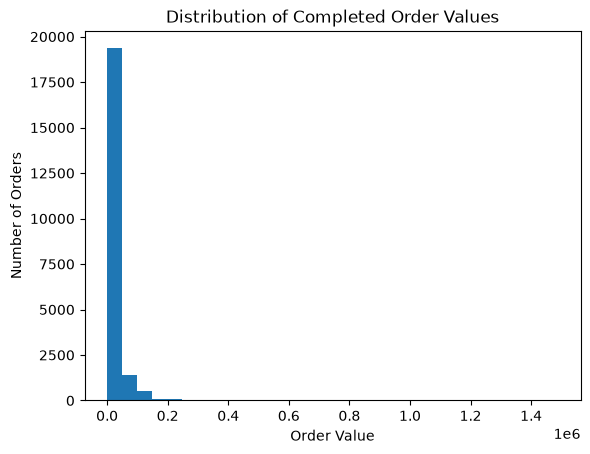

In [137]:
import matplotlib.pyplot as plt

plt.hist(order_values, bins=30)
plt.title("Distribution of Completed Order Values")
plt.xlabel("Order Value")
plt.ylabel("Number of Orders")
plt.show()


### 2. Quantity Distribution

In [139]:
# reviewing values in general. range and outliers
df_completed["Quantity"].value_counts().sort_index()

Quantity
1     34039
2      7669
3      2390
4       684
12        1
15        4
20        6
Name: count, dtype: int64

### 3. Discount Distribution

In [140]:
df_completed["Discount_Pct"].describe()

count    44693.000000
mean         0.086953
std          0.096177
min          0.000000
25%          0.000000
50%          0.050000
75%          0.150000
max          0.300000
Name: Discount_Pct, dtype: float64

In [141]:
df_completed["Discount_Pct"].value_counts(
    dropna=False
).sort_index()

# understand how common each discount level is while still showing missing values.

Discount_Pct
0.00    19786
0.05     4045
0.10     5978
0.15     5155
0.20     4603
0.25     2910
0.30     2216
NaN       100
Name: count, dtype: int64

### 4. Gross Margin Distribution

In [142]:
df_completed["Gross_Margin_Pct"].describe()

count    44793.000000
mean        30.090438
std         12.410067
min        -53.490000
25%         22.980000
50%         30.360000
75%         40.190000
max         52.090000
Name: Gross_Margin_Pct, dtype: float64

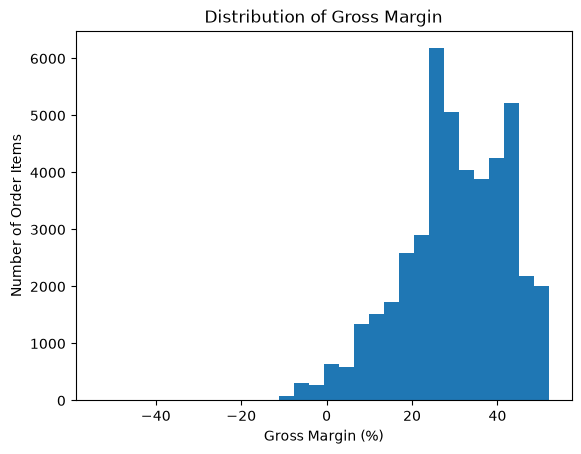

In [143]:
plt.hist(df_completed["Gross_Margin_Pct"], bins=30)
plt.title("Distribution of Gross Margin")
plt.xlabel("Gross Margin (%)")
plt.ylabel("Number of Order Items")
plt.show()

In [144]:
# For large quantities
df_completed[df_completed["Quantity"] > 3].sort_values(
    "Quantity", ascending=False
)

,Line_ID,Order_ID,Product_ID,Quantity,Unit_Price,Unit_Cost,Discount_Pct,Gross_Sales,Discount_Amount,Net_Sales,...,Promo_Code,Customer_Segment,City,Signup_Date,Acquisition_Channel,Year,Month,Month_Name,Quarter,Year_Month
14966,L0014972,O007180,P0084,20,1760.0,1230.0,0.05,35200.0,1760.0,33440.0,...,NONE,Home Office,Multan,2022-08-25,Paid Search,2025,5,May,2,2025-05
22601,L0022610,O010847,P0051,20,3620.0,1890.0,0.10,72400.0,7240.0,65160.0,...,NONE,Consumer,Gujranwala,2025-07-21,Organic Search,2024,11,November,4,2024-11
26959,L0026970,O012965,P0190,20,13350.0,10040.0,0.10,267000.0,26700.0,240300.0,...,NONE,Consumer,Lahore,2023-04-09,Organic Search,2024,8,August,3,2024-08
36569,L0036582,O017560,P0185,20,12880.0,8350.0,0.10,257600.0,25760.0,231840.0,...,SAVE15,Home Office,Faisalabad,2022-08-24,Email,2025,12,December,4,2025-12
46655,L0046673,O022403,P0026,20,10350.0,6600.0,0.05,207000.0,10350.0,196650.0,...,NONE,Small Business,Faisalabad,2022-12-29,Organic Search,2024,10,October,4,2024-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49251,L0049269,O023657,P0012,4,5070.0,2940.0,0.00,20280.0,0.0,20280.0,...,NONE,Consumer,Karachi,2024-12-02,Referral,2024,4,April,2,2024-04
49297,L0049315,O023684,P0174,4,900.0,630.0,0.00,3600.0,0.0,3600.0,...,NONE,Home Office,Karachi,2024-07-02,Social Media,2025,4,April,2,2025-04
49629,L0049647,O023834,P0092,4,10220.0,4930.0,0.00,40880.0,0.0,40880.0,...,NONE,Consumer,Peshawar,2024-07-22,Referral,2025,9,September,3,2025-09
49704,L0049722,O023871,P0046,4,3460.0,2520.0,0.05,13840.0,692.0,13148.0,...,FREESHIP,Home Office,Faisalabad,2025-03-15,Organic Search,2024,4,April,2,2024-04


In [145]:
# for negative Gross_Margin_Pct values
negative_margin = df_completed[
    df_completed["Gross_Margin_Pct"] < 0
]

negative_margin

,Line_ID,Order_ID,Product_ID,Quantity,Unit_Price,Unit_Cost,Discount_Pct,Gross_Sales,Discount_Amount,Net_Sales,...,Promo_Code,Customer_Segment,City,Signup_Date,Acquisition_Channel,Year,Month,Month_Name,Quarter,Year_Month
176,L0000177,O000091,P0061,1,2140.0,1570.0,0.3,2140.0,642.0,1498.0,...,NONE,Consumer,Peshawar,2025-04-26,Organic Search,2024,12,December,4,2024-12
293,L0000294,O000148,P0193,1,11050.0,7780.0,0.3,11050.0,3315.0,7735.0,...,SAVE15,Consumer,Peshawar,2023-07-28,Paid Search,2024,11,November,4,2024-11
351,L0000352,O000177,P0041,1,11910.0,8880.0,0.3,11910.0,3573.0,8337.0,...,NONE,Consumer,Islamabad,2024-07-04,Social Media,2025,11,November,4,2025-11
428,L0000429,O000217,P0089,1,1790.0,1310.0,0.3,1790.0,537.0,1253.0,...,SAVE15,Consumer,Lahore,2023-11-18,Email,2025,11,November,4,2025-11
438,L0000439,O000220,P0099,1,15010.0,11350.0,0.3,15010.0,4503.0,10507.0,...,NONE,Consumer,Gujranwala,2025-01-30,Organic Search,2024,7,July,3,2024-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49316,L0049334,O023692,P0109,1,6660.0,4850.0,0.3,6660.0,1998.0,4662.0,...,WELCOME10,Home Office,Gujranwala,2024-04-24,Organic Search,2024,9,September,3,2024-09
49436,L0049454,O023744,P0227,1,12420.0,9180.0,0.3,12420.0,3726.0,8694.0,...,WELCOME10,Home Office,Lahore,2025-09-02,Organic Search,2024,11,November,4,2024-11
49651,L0049669,O023842,P0182,2,1870.0,1390.0,0.3,3740.0,1122.0,2618.0,...,NONE,Home Office,Gujranwala,2024-08-24,Referral,2024,12,December,4,2024-12
49794,L0049813,O023915,P0188,1,32140.0,23880.0,0.3,32140.0,9642.0,22498.0,...,NONE,Consumer,Karachi,2025-07-16,Organic Search,2025,11,November,4,2025-11


In [146]:
df_completed.groupby("Order_ID")["Net_Sales"].sum().sort_values(
    ascending=False
).head(10)

Order_ID
O006324    1488971.5
O004516     513702.0
O021829     504530.0
O005461     488400.0
O005356     470229.0
O006400     459312.0
O009795     449616.0
O017125     443862.0
O007824     394440.0
O013684     390302.0
Name: Net_Sales, dtype: float64

Order with ID = O006324 is an outlier. 
To further investigate, checking other attributes of this grain.


In [147]:
df_completed[
    df_completed["Order_ID"] == "O006324"
][[
    "Order_ID",
    "Customer_ID",
    "Customer_Segment",
    "Product_Name",
    "Category",
    "Quantity",
    "Unit_Price",
    "Discount_Pct",
    "Net_Sales"
]]

,Order_ID,Customer_ID,Customer_Segment,Product_Name,Category,Quantity,Unit_Price,Discount_Pct,Net_Sales
13168,O006324,C03536,Consumer,Computer Accessories Item 09,Electronics,12,122100.0,0.00,1465200.0
13169,O006324,C03536,Consumer,Grooming Item 07,Beauty & Personal Care,1,11410.0,0.00,11410.0
13170,O006324,C03536,Consumer,Fitness Item 04,Sports & Outdoors,1,8790.0,0.15,7471.5
13171,O006324,C03536,Consumer,Outdoor Item 09,Sports & Outdoors,1,4890.0,0.00,4890.0


The order-value distribution is strongly right-skewed, with a small number of high-value orders substantially increasing the mean. Therefore, both mean and median order values should be considered when evaluating typical order size.

High-value order investigation: Order O006324 was identified as an extreme value with total Net Sales of approximately 1.49 million. Inspection showed that most of the value came from the purchase of 12 units of a high-priced product. As the quantity, price, and calculated sales were internally consistent, the order was retained as a valid outlier.

In [148]:
len(negative_margin)

706

In [149]:
negative_margin["Gross_Margin_Pct"].describe()

count    706.000000
mean      -4.637946
std        3.355838
min      -53.490000
25%       -6.570000
50%       -4.650000
75%       -2.040000
max       -0.150000
Name: Gross_Margin_Pct, dtype: float64

In [152]:
negative_margin["Discount_Pct"].value_counts(
    dropna=False
).sort_index()

Discount_Pct
0.00      2
0.15      1
0.25    103
0.30    600
Name: count, dtype: int64

In [151]:
# checking how many negative_margin values are there for relevant categories of products
negative_margin.groupby("Category").size().sort_values(
    ascending=False
)

Category
Office & Stationery       204
Beauty & Personal Care    125
Home & Living             125
Sports & Outdoors         110
Electronics                91
Fashion                    51
dtype: int64

In [153]:
# Checking what prices (of sales giving negative margins) are equal to unit cost and what below unit cost
print(
    "Price below cost:",
    (negative_margin["Unit_Price"] < negative_margin["Unit_Cost"]).sum()
)

print(
    "Price >= cost:",
    (negative_margin["Unit_Price"] >= negative_margin["Unit_Cost"]).sum()
)

Price below cost: 3
Price >= cost: 703


That tells us something useful: discounting is almost certainly the main reason for the negative margins, not erroneous base prices.

Of the 706 loss-making completed order lines, only 3 had Unit_Price < Unit_Cost. The other 703 had a selling price at or above cost before discounting. After discounts were applied, their Net_Sales fell below Total_Cost.

The losses are generally modest too: median margin is −4.65%, and 75% of these rows are no worse than roughly −6.57%. The −53.49% minimum is therefore unusually extreme and may correspond to one of the three price-below-cost cases.

Negative Margin Investigation: 706 completed order lines generated negative gross margins. Of these, 703 (99.6%) had discounts of 25% or 30%, while 703 also had unit prices equal to or greater than unit costs before discounts. This indicates that high discount levels, rather than generally incorrect base pricing, are the primary driver of negative margins.

Distribution Analysis Completed

Several meaningful patterns are found rather than just producing descriptive statistics:

Order values are strongly right-skewed.
The exceptionally large 1.49M order was investigated and retained as a legitimate outlier.
High quantities exist but shouldn't automatically be treated as errors.
Typical recorded discounts are relatively modest, but 25–30% discounts are strongly associated with negative margins.
Overall gross margins center around roughly 30%, while a small subset is loss-making.

## Time-Based Sales Analysis

### Monthly Trends

In [154]:
# Monthly Sales of completed order
monthly_sales = df_completed.groupby("Year_Month")["Net_Sales"].sum()
monthly_sales

Year_Month
2024-01    16989602.0
2024-02    17481063.0
2024-03    17336778.0
2024-04    16735076.5
2024-05    15035812.5
2024-06    16766200.5
2024-07    17988796.0
2024-08    18913908.0
2024-09    18178351.0
2024-10    18474082.5
2024-11    26956018.0
2024-12    28711002.5
2025-01    17542486.5
2025-02    15961037.0
2025-03    16935265.5
2025-04    17781924.0
2025-05    18899208.5
2025-06    18453963.0
2025-07    17452601.5
2025-08    18134621.0
2025-09    16660799.5
2025-10    17773040.5
2025-11    25539361.0
2025-12    31794476.0
Freq: M, Name: Net_Sales, dtype: float64

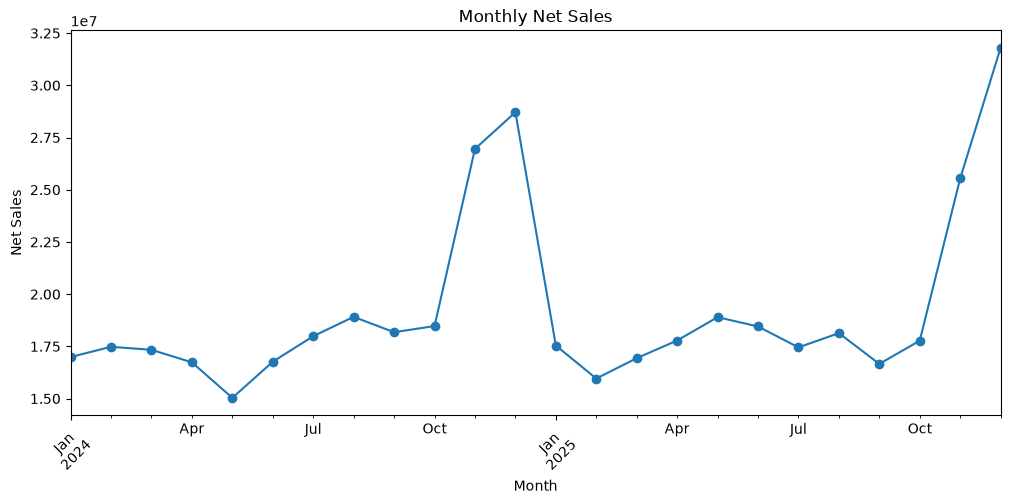

In [155]:
# Visualizing by plotting the sales
monthly_sales.plot(
    kind="line",
    marker="o",
    figsize=(12, 5)
)

plt.title("Monthly Net Sales")
plt.xlabel("Month")
plt.ylabel("Net Sales")
plt.xticks(rotation=45)
plt.show()

In [157]:
# Monthly profits
monthly_profit = df_completed.groupby("Year_Month")["Gross_Profit"].sum()

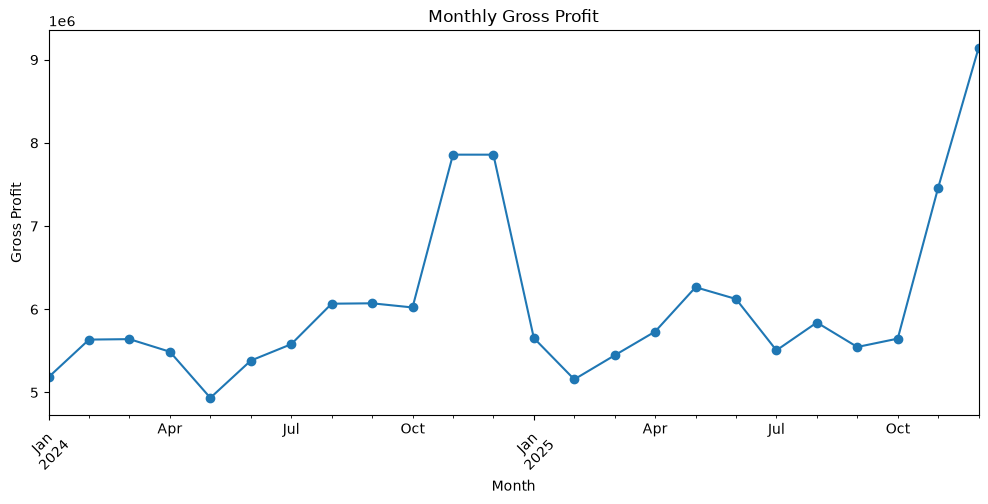

In [158]:
monthly_profit.plot(
    kind="line",
    marker="o",
    figsize=(12, 5)
)

plt.title("Monthly Gross Profit")
plt.xlabel("Month")
plt.ylabel("Gross Profit")
plt.xticks(rotation=45)
plt.show()

Both metrics follow broadly the same monthly pattern. When Net Sales rise, Gross Profit generally rises as well. That suggests the large sales months are also contributing meaningfully to profit rather than merely generating revenue through very low-margin transactions.

The most obvious feature is the year-end surge. In both 2024 and 2025, November and December rise sharply relative to the preceding months. December 2025 is the strongest month in both Net Sales and Gross Profit. That repeated pattern gives us some evidence of year-end seasonality, although with only two years of data we should describe it cautiously rather than claim a long-term seasonal trend.

Outside November–December, performance is much more stable. There are some smaller fluctuations, with May 2024 and February 2025 appearing relatively weak, but nothing comparable to the year-end increases.

One interesting difference is that the November-to-December 2024 increase in sales is noticeable, while Gross Profit is almost flat. That could mean December 2024 generated additional sales at a lower average margin. 

In [159]:
monthly_performance = df_completed.groupby("Year_Month").agg({
    "Net_Sales": "sum",
    "Gross_Profit": "sum",
    "Order_ID": "nunique"
})

monthly_performance

,Net_Sales,Gross_Profit,Order_ID
Year_Month,,,
2024-01,16989602.0,5184752.0,843
2024-02,17481063.0,5635733.0,774
2024-03,17336778.0,5641088.0,779
2024-04,16735076.5,5489456.5,772
2024-05,15035812.5,4935282.5,777
2024-06,16766200.5,5382950.5,792
2024-07,17988796.0,5580326.0,831
2024-08,18913908.0,6067108.0,828
2024-09,18178351.0,6071871.0,805


In [160]:
# Adding Profit_Margin_Pct

monthly_performance["Profit_Margin_Pct"] = (
    monthly_performance["Gross_Profit"]
    / monthly_performance["Net_Sales"]
) * 100

monthly_performance

,Net_Sales,Gross_Profit,Order_ID,Profit_Margin_Pct
Year_Month,,,,
2024-01,16989602.0,5184752.0,843,30.517207
2024-02,17481063.0,5635733.0,774,32.239075
2024-03,17336778.0,5641088.0,779,32.538272
2024-04,16735076.5,5489456.5,772,32.802100
2024-05,15035812.5,4935282.5,777,32.823517
2024-06,16766200.5,5382950.5,792,32.105965
2024-07,17988796.0,5580326.0,831,31.021120
2024-08,18913908.0,6067108.0,828,32.077496
2024-09,18178351.0,6071871.0,805,33.401660


From November to December 2024:

Profit margin fell from 29.15% to 27.37%
That's a decline of about 1.78 percentage points
Net Sales increased, but Gross Profit remained almost flat.

So December generated more revenue, but each unit of revenue was, on average, less profitable. 
A reasonable hypothesis is heavier discounting in December, but we shouldn't conclude that without testing it.

In [161]:
# Checking November vs December

df_completed[
    (df_completed["Year"] == 2024) &
    (df_completed["Month"].isin([11, 12]))
].groupby("Month")["Discount_Pct"].mean()

Month
11    0.121256
12    0.119181
Name: Discount_Pct, dtype: float64

In [162]:
# Checking how much is the actual discount in Nov an Dec
df_completed[
    (df_completed["Year"] == 2024) &
    (df_completed["Month"].isin([11, 12]))
].groupby(["Month", "Discount_Pct"]).size()

Month  Discount_Pct
11     0.00             875
       0.05             161
       0.10             296
       0.15             434
       0.20             474
       0.25             299
       0.30             199
12     0.00            1003
       0.05             180
       0.10             301
       0.15             453
       0.20             500
       0.25             332
       0.30             221
dtype: int64

### Annual Trends

In [163]:
yearly_performance = df_completed.groupby("Year").agg({
    "Net_Sales": "sum",
    "Gross_Profit": "sum",
    "Quantity": "sum",
    "Order_ID": "nunique"
})

yearly_performance

,Net_Sales,Gross_Profit,Quantity,Order_ID
Year,,,,
2024,229566690.5,71727850.5,29762,10766
2025,232928784.0,73525546.0,29713,10760


In [164]:
# Renaming to more meaningful headers
yearly_performance = yearly_performance.rename(columns={
    "Quantity": "Units_Sold",
    "Order_ID": "Total_Orders"
})

yearly_performance

,Net_Sales,Gross_Profit,Units_Sold,Total_Orders
Year,,,,
2024,229566690.5,71727850.5,29762,10766
2025,232928784.0,73525546.0,29713,10760


In [165]:
#  Average Order Value
yearly_performance["AOV"] = (
    yearly_performance["Net_Sales"] /
    yearly_performance["Total_Orders"]
)

yearly_performance

,Net_Sales,Gross_Profit,Units_Sold,Total_Orders,AOV
Year,,,,,
2024,229566690.5,71727850.5,29762,10766,21323.303966
2025,232928784.0,73525546.0,29713,10760,21647.656506


In [166]:
# Annual profit margin pct
yearly_performance["Profit_Margin_Pct"] = (
    yearly_performance["Gross_Profit"] /
    yearly_performance["Net_Sales"]
) * 100

yearly_performance

,Net_Sales,Gross_Profit,Units_Sold,Total_Orders,AOV,Profit_Margin_Pct
Year,,,,,,
2024,229566690.5,71727850.5,29762,10766,21323.303966,31.244886
2025,232928784.0,73525546.0,29713,10760,21647.656506,31.565676


### Year over Year Growth

In [167]:
yoy_growth = yearly_performance.pct_change() * 100

yoy_growth

,Net_Sales,Gross_Profit,Units_Sold,Total_Orders,AOV,Profit_Margin_Pct
Year,,,,,,
2024,NaN,NaN,NaN,NaN,NaN,NaN
2025,1.464539,2.506273,-0.164639,-0.055731,1.521118,1.026697


Net Sales increased modestly by 1.46% in 2025. Total orders and units sold remained almost unchanged, declining by 0.06% and 0.16% respectively, while AOV increased by 1.52%. This indicates that sales growth was primarily driven by higher order values rather than increased transaction volume. Gross Profit grew faster than Net Sales at 2.51%, accompanied by an improvement in overall profit margin.

## Product and Category Performance 

Questions to be addressed:
1. Which categories generate the most sales?
2. Which generate the most gross profit?
3. Which have the strongest/weakest margins?
4. Which categories are most exposed to loss-making transactions?

### Category Performace Summary

In [168]:
category_performance = df_completed.groupby("Category").agg({
    "Net_Sales": "sum",
    "Gross_Profit": "sum",
    "Quantity": "sum",
    "Order_ID": "nunique"
})

category_performance

,Net_Sales,Gross_Profit,Quantity,Order_ID
Category,,,,
Beauty & Personal Care,33441021.0,9076051.0,9311,6306
Electronics,219270695.0,70848455.0,8787,5899
Fashion,37580256.0,12033146.0,8338,5614
Home & Living,50395812.0,15376382.0,10928,7036
Office & Stationery,34128985.0,9732663.0,11582,7483
Sports & Outdoors,87678705.5,28186699.5,10529,6832


In [169]:
# Renaming for readability
category_performance = category_performance.rename(columns={
    "Quantity": "Units_Sold",
    "Order_ID": "Total_Orders"
})

category_performance

,Net_Sales,Gross_Profit,Units_Sold,Total_Orders
Category,,,,
Beauty & Personal Care,33441021.0,9076051.0,9311,6306
Electronics,219270695.0,70848455.0,8787,5899
Fashion,37580256.0,12033146.0,8338,5614
Home & Living,50395812.0,15376382.0,10928,7036
Office & Stationery,34128985.0,9732663.0,11582,7483
Sports & Outdoors,87678705.5,28186699.5,10529,6832


In [170]:
# Calculating and adding Profit Margin Pct in catergory performance
category_performance["Profit_Margin_Pct"] = (
    category_performance["Gross_Profit"] /
    category_performance["Net_Sales"]
) * 100

category_performance

,Net_Sales,Gross_Profit,Units_Sold,Total_Orders,Profit_Margin_Pct
Category,,,,,
Beauty & Personal Care,33441021.0,9076051.0,9311,6306,27.140472
Electronics,219270695.0,70848455.0,8787,5899,32.310955
Fashion,37580256.0,12033146.0,8338,5614,32.019862
Home & Living,50395812.0,15376382.0,10928,7036,30.511230
Office & Stationery,34128985.0,9732663.0,11582,7483,28.517294
Sports & Outdoors,87678705.5,28186699.5,10529,6832,32.147714


In [171]:
category_performance.sort_values(
    "Net_Sales", ascending=False
)

,Net_Sales,Gross_Profit,Units_Sold,Total_Orders,Profit_Margin_Pct
Category,,,,,
Electronics,219270695.0,70848455.0,8787,5899,32.310955
Sports & Outdoors,87678705.5,28186699.5,10529,6832,32.147714
Home & Living,50395812.0,15376382.0,10928,7036,30.511230
Fashion,37580256.0,12033146.0,8338,5614,32.019862
Office & Stationery,34128985.0,9732663.0,11582,7483,28.517294
Beauty & Personal Care,33441021.0,9076051.0,9311,6306,27.140472


### Visualizing Sales and Profit

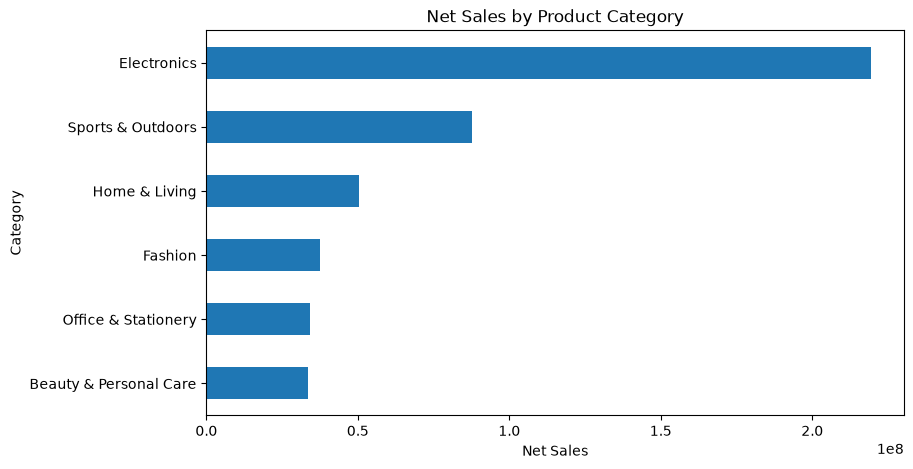

In [172]:
# Bar Chart of Category vs Net Sales
category_performance["Net_Sales"].sort_values().plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Net Sales by Product Category")
plt.xlabel("Net Sales")
plt.ylabel("Category")
plt.show()

In [173]:
category_performance["Gross_Profit"].sort_values(ascending=False)

Category
Electronics               70848455.0
Sports & Outdoors         28186699.5
Home & Living             15376382.0
Fashion                   12033146.0
Office & Stationery        9732663.0
Beauty & Personal Care     9076051.0
Name: Gross_Profit, dtype: float64

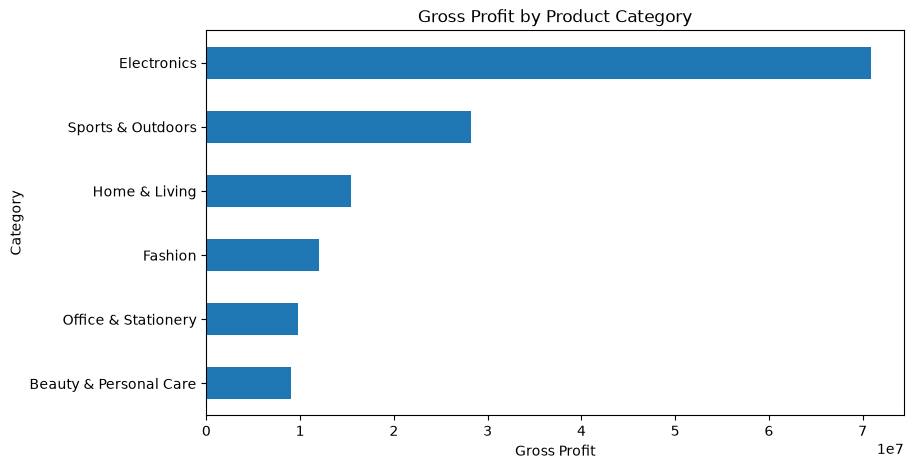

In [174]:
# Gross Profit Chart

category_performance["Gross_Profit"].sort_values().plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Gross Profit by Product Category")
plt.xlabel("Gross Profit")
plt.ylabel("Category")
plt.show()

### Negative Margin Rate by Category

Question to be answered: 
What percentage of completed order lines in each category are loss-making?
we need to A: calculate category_total_lines and 
           B: category_negative_lines. 
Then we can calculate negative margin rate by ratio of A and B.

In [175]:
# Completed Order line per Category
category_total_lines = df_completed.groupby("Category").size()
category_total_lines

Category
Beauty & Personal Care    7084
Electronics               6670
Fashion                   6283
Home & Living             8157
Office & Stationery       8759
Sports & Outdoors         7840
dtype: int64

In [176]:
# negative margin lines
category_negative_lines = negative_margin.groupby("Category").size()
category_negative_lines

Category
Beauty & Personal Care    125
Electronics                91
Fashion                    51
Home & Living             125
Office & Stationery       204
Sports & Outdoors         110
dtype: int64

Office & Stationery with 204 negative_margin_lines is worth investigating.


In [179]:
# negative margin rate

negative_margin_rate = (
    category_negative_lines / category_total_lines
) * 100

negative_margin_rate.sort_values(ascending=False)

Category
Office & Stationery       2.329033
Beauty & Personal Care    1.764540
Home & Living             1.532426
Sports & Outdoors         1.403061
Electronics               1.364318
Fashion                   0.811714
dtype: float64

### Investigating Subcategories Negative Lines
To check the vastness of each category for negative lines. If one categories is due to its one negative subcategory, then there is a potential error.

In [180]:
subcategory_performance = df_completed.groupby(
    ["Category", "Subcategory"]
).agg({
    "Net_Sales": "sum",
    "Gross_Profit": "sum",
    "Quantity": "sum"
})

subcategory_performance["Profit_Margin_Pct"] = (
    subcategory_performance["Gross_Profit"] /
    subcategory_performance["Net_Sales"]
) * 100

subcategory_performance

Net_Sales  Gross_Profit  \
Category               Subcategory                                      
Beauty & Personal Care Fragrance              9803076.0     2407276.0   
                       Grooming               5694554.5     1942684.5   
                       Hair Care              9862651.0     2299001.0   
                       Skincare               8080739.5     2427089.5   
Electronics            Audio                 95525739.0    29968429.0   
                       Computer Accessories  77244398.5    24883858.5   
                       Laptops               22733588.5     7399538.5   
                       Mobile Accessories    23766969.0     8596629.0   
Fashion                Bags                   8773582.5     3056362.5   
                       Footwear               7085135.5     2281085.5   
                       Men's Clothing        13552392.5     4195172.5   
                       Women's Clothing       8169145.5     2500525.5   
Home & Living          Bedding               15115895.5     4265825.5   
                       Home Decor            13162638.0     4917598.0   
                       Kitchen               13482033.5     3158283.5   
                       Storage                8635245.0     3034675.0   
Office & Stationery    Desk Accessories       2705112.5     1035912.5   
                       Office Equipment      10633589.5     2928579.5   
                       Paper Products        11523657.0     2864577.0   
                       Writing                9266626.0     2903594.0   
Sports & Outdoors      Cycling               11064338.5     3819268.5   
                       Fitness               19777326.0     6360820.0   
                       Outdoor               13567452.5     3783172.5   
                       Sports Accessories    43269588.5    14223438.5   

                                             Quantity  Profit_Margin_Pct  
Category               Subcategory                                        
Beauty & Personal Care Fragrance                 2812          24.556333  
                       Grooming                  2016          34.114776  
                       Hair Care                 2310          23.310173  
                       Skincare                  2173          30.035487  
Electronics            Audio                     2654          31.372099  
                       Computer Accessories      2177          32.214450  
                       Laptops                   1633          32.548924  
                       Mobile Accessories        2323          36.170489  
Fashion                Bags                      2155          34.835969  
                       Footwear                  1667          32.195369  
                       Men's Clothing            3072          30.955217  
                       Women's Clothing          1444          30.609389  
Home & Living          Bedding                   3069          28.220792  
                       Home Decor                2710          37.360277  
                       Kitchen                   2436          23.425869  
                       Storage                   2713          35.142894  
Office & Stationery    Desk Accessories          2076          38.294618  
                       Office Equipment          3312          27.540837  
                       Paper Products            2606          24.858229  
                       Writing                   3588          31.333886  
Sports & Outdoors      Cycling                   2315          34.518724  
                       Fitness                   2971          32.162184  
                       Outdoor                   2480          27.884177  
                       Sports Accessories        2763          32.871675

In [181]:
category_performance["Profit_Margin_Pct"].sort_values(ascending=False)

Category
Electronics               32.310955
Sports & Outdoors         32.147714
Fashion                   32.019862
Home & Living             30.511230
Office & Stationery       28.517294
Beauty & Personal Care    27.140472
Name: Profit_Margin_Pct, dtype: float64

Sub-conclusion
Electronics dominates the business. Its Net Sales of 219.27M are about 2.5× Sports & Outdoors, the second-largest category. Electronics also produces the highest Gross Profit at 70.85M and has the highest category margin at 32.31%. So its sales leadership is not coming at the expense of profitability.

At the other end, Beauty & Personal Care has the lowest Net Sales at 33.44M, lowest Gross Profit at 9.08M, and the lowest overall margin at 27.14%. That combination makes it worth investigating further at the subcategory/product level.

In [182]:
negative_margin_rate.sort_values(ascending=False)

Category
Office & Stationery       2.329033
Beauty & Personal Care    1.764540
Home & Living             1.532426
Sports & Outdoors         1.403061
Electronics               1.364318
Fashion                   0.811714
dtype: float64

In [186]:
# Adding new metric "Sale_Contribution_Pct" to catergory_performance table
category_performance["Sales_Contribution_Pct"] = (
    category_performance["Net_Sales"] /
    category_performance["Net_Sales"].sum()
) * 100

In [185]:
# checking what percentage of Electronics sales contributed 
category_performance[
    ["Net_Sales", "Sales_Contribution_Pct"]
].sort_values("Net_Sales", ascending=False)

,Net_Sales,Sales_Contribution_Pct
Category,,
Electronics,219270695.0,47.410344
Sports & Outdoors,87678705.5,18.957743
Home & Living,50395812.0,10.896498
Fashion,37580256.0,8.125540
Office & Stationery,34128985.0,7.379312
Beauty & Personal Care,33441021.0,7.230562


In [187]:
# Top five subcategory sales
subcategory_performance.sort_values(
    "Net_Sales", ascending=False
).head(5)

Net_Sales  Gross_Profit  Quantity  \
Category          Subcategory                                                
Electronics       Audio                 95525739.0    29968429.0      2654   
                  Computer Accessories  77244398.5    24883858.5      2177   
Sports & Outdoors Sports Accessories    43269588.5    14223438.5      2763   
Electronics       Mobile Accessories    23766969.0     8596629.0      2323   
                  Laptops               22733588.5     7399538.5      1633   

                                        Profit_Margin_Pct  
Category          Subcategory                              
Electronics       Audio                         31.372099  
                  Computer Accessories          32.214450  
Sports & Outdoors Sports Accessories            32.871675  
Electronics       Mobile Accessories            36.170489  
                  Laptops                       32.548924

In [188]:
# Bottom five subcatergory sales
subcategory_performance.sort_values(
    "Net_Sales"
).head(5)

,,Net_Sales,Gross_Profit,Quantity,Profit_Margin_Pct
Category,Subcategory,,,,
Office & Stationery,Desk Accessories,2705112.5,1035912.5,2076,38.294618
Beauty & Personal Care,Grooming,5694554.5,1942684.5,2016,34.114776
Fashion,Footwear,7085135.5,2281085.5,1667,32.195369
Beauty & Personal Care,Skincare,8080739.5,2427089.5,2173,30.035487
Fashion,Women's Clothing,8169145.5,2500525.5,1444,30.609389


In [189]:
# 5 lowest margins

subcategory_performance.sort_values(
    "Profit_Margin_Pct"
).head(5)

Net_Sales  Gross_Profit  Quantity  \
Category               Subcategory                                            
Beauty & Personal Care Hair Care          9862651.0     2299001.0      2310   
Home & Living          Kitchen           13482033.5     3158283.5      2436   
Beauty & Personal Care Fragrance          9803076.0     2407276.0      2812   
Office & Stationery    Paper Products    11523657.0     2864577.0      2606   
                       Office Equipment  10633589.5     2928579.5      3312   

                                         Profit_Margin_Pct  
Category               Subcategory                          
Beauty & Personal Care Hair Care                 23.310173  
Home & Living          Kitchen                   23.425869  
Beauty & Personal Care Fragrance                 24.556333  
Office & Stationery    Paper Products            24.858229  
                       Office Equipment          27.540837

In [190]:
# Top 5 subcategories by Net_sales
subcategory_performance["Net_Sales"].sort_values(ascending=False).head(5)

Category           Subcategory         
Electronics        Audio                   95525739.0
                   Computer Accessories    77244398.5
Sports & Outdoors  Sports Accessories      43269588.5
Electronics        Mobile Accessories      23766969.0
                   Laptops                 22733588.5
Name: Net_Sales, dtype: float64

In [191]:
# Bottom 5 subcategories by Net sales
subcategory_performance["Net_Sales"].sort_values(ascending=False).tail(5)

Category                Subcategory     
Fashion                 Women's Clothing    8169145.5
Beauty & Personal Care  Skincare            8080739.5
Fashion                 Footwear            7085135.5
Beauty & Personal Care  Grooming            5694554.5
Office & Stationery     Desk Accessories    2705112.5
Name: Net_Sales, dtype: float64

In [192]:
# Bottom 5 subcategories by Profit Margins
round(subcategory_performance["Profit_Margin_Pct"].sort_values(ascending=False).tail(5), 2)

Category                Subcategory     
Office & Stationery     Office Equipment    27.54
                        Paper Products      24.86
Beauty & Personal Care  Fragrance           24.56
Home & Living           Kitchen             23.43
Beauty & Personal Care  Hair Care           23.31
Name: Profit_Margin_Pct, dtype: float64

In [194]:
#Sales contribution by Category
category_performance["Sales_Contribution_Pct"] = (
    category_performance["Net_Sales"] /
    category_performance["Net_Sales"].sum()
) * 100

round(category_performance["Sales_Contribution_Pct"].sort_values(ascending=False), 2)

Category
Electronics               47.41
Sports & Outdoors         18.96
Home & Living             10.90
Fashion                    8.13
Office & Stationery        7.38
Beauty & Personal Care     7.23
Name: Sales_Contribution_Pct, dtype: float64

The above findings are useful. Audio leads subcategory sales at 95.53M, followed by Computer Accessories at 77.24M. Electronics therefore isn't being driven by only one subcategory. Electronics contributes 47.41% of all completed Net Sales, which confirms how important that category is to the overall business.

The bottom-sales list and bottom-margin list are also noticeably different. For example, Desk Accessories has the lowest sales, but it isn't among the five lowest-margin subcategories. Conversely, Hair Care has the lowest margin at 23.31%, which shows why we shouldn't equate low sales with poor profitability.

### Perfomance by Product

In [195]:
# Product performance summary/table
product_performance = df_completed.groupby(
    ["Product_ID", "Product_Name"]
).agg({
    "Net_Sales": "sum",
    "Gross_Profit": "sum",
    "Quantity": "sum"
})

product_performance = product_performance.rename(
    columns={"Quantity": "Units_Sold"}
)

product_performance["Profit_Margin_Pct"] = (
    product_performance["Gross_Profit"] /
    product_performance["Net_Sales"]
) * 100

product_performance

,,Net_Sales,Gross_Profit,Units_Sold,Profit_Margin_Pct
Product_ID,Product_Name,,,,
P0001,Laptops Item 01,136278.0,54138.0,111,39.726148
P0002,Laptops Item 02,142746.0,47346.0,106,33.168005
P0003,Laptops Item 03,2107692.0,394012.0,124,18.694003
P0004,Laptops Item 04,249641.0,75571.0,103,30.271870
P0005,Laptops Item 05,2426821.5,903581.5,226,37.233126
...,...,...,...,...,...
P0236,Office Equipment Item 06,314902.0,89332.0,103,28.368191
P0237,Office Equipment Item 07,1263684.0,566494.0,403,44.828770
P0238,Office Equipment Item 08,65772.0,14022.0,115,21.319102


In [196]:
# Top 10 products by Net Sales
product_performance["Net_Sales"].sort_values(
    ascending=False
).head(10)

Product_ID  Product_Name                
P0039       Computer Accessories Item 09    28083000.0
P0015       Audio Item 05                   26081946.0
P0019       Audio Item 09                   25854419.5
P0034       Computer Accessories Item 04    15961368.0
P0017       Audio Item 07                   14480588.0
P0187       Sports Accessories Item 07      13233912.0
P0038       Computer Accessories Item 08    11759190.0
P0014       Audio Item 04                   11686845.5
P0016       Audio Item 06                   10155849.0
P0169       Fitness Item 09                  9268168.0
Name: Net_Sales, dtype: float64

In [197]:
# Top 10 products by Gross Profit
product_performance["Gross_Profit"].sort_values(
    ascending=False
).head(10)

Product_ID  Product_Name                
P0039       Computer Accessories Item 09    9913000.0
P0019       Audio Item 09                   9657109.5
P0015       Audio Item 05                   6065466.0
P0034       Computer Accessories Item 04    5467828.0
P0014       Audio Item 04                   5411145.5
P0187       Sports Accessories Item 07      5155632.0
P0029       Mobile Accessories Item 09      4070746.0
P0016       Audio Item 06                   3843699.0
P0038       Computer Accessories Item 08    3831390.0
P0010       Laptops Item 10                 3549024.0
Name: Gross_Profit, dtype: float64

In [198]:
# Bottom 10 products by Profit Margin
round(product_performance["Profit_Margin_Pct"].sort_values().head(10), 2)

Product_ID  Product_Name                
P0035       Computer Accessories Item 05    15.65
P0128       Skincare Item 08                15.92
P0207       Writing Item 07                 16.10
P0108       Footwear Item 08                16.69
P0032       Computer Accessories Item 02    16.70
P0173       Outdoor Item 03                 16.72
P0213       Desk Accessories Item 03        16.79
P0161       Fitness Item 01                 16.86
P0058       Home Decor Item 08              17.07
P0225       Paper Products Item 05          17.29
Name: Profit_Margin_Pct, dtype: float64

In [199]:
# Top 10 products by Profit margins
product_performance.sort_values(
    "Profit_Margin_Pct"
, ascending=False).head(10)

,,Net_Sales,Gross_Profit,Units_Sold,Profit_Margin_Pct
Product_ID,Product_Name,,,,
P0149,Grooming Item 09,339003.0,161493.0,291,47.637632
P0025,Mobile Accessories Item 05,526105.0,250065.0,268,47.531386
P0117,Bags Item 07,352005.5,167085.5,134,47.466730
P0092,Women's Clothing Item 02,1311737.0,621537.0,140,47.382745
P0053,Home Decor Item 03,1523606.0,712906.0,242,46.790706
P0210,Writing Item 10,85025.0,39425.0,48,46.368715
P0014,Audio Item 04,11686845.5,5411145.5,114,46.301164
P0029,Mobile Accessories Item 09,8797636.0,4070746.0,427,46.270907
P0106,Footwear Item 06,697774.5,322174.5,313,46.171722


In [200]:
# Bottom 10 products by Profit margins
product_performance.sort_values(
    "Profit_Margin_Pct"
).head(10)

,,Net_Sales,Gross_Profit,Units_Sold,Profit_Margin_Pct
Product_ID,Product_Name,,,,
P0035,Computer Accessories Item 05,2293824.0,358884.0,102,15.645664
P0128,Skincare Item 08,3156767.0,502487.0,303,15.917773
P0207,Writing Item 07,480750.0,77418.0,353,16.103588
P0108,Footwear Item 08,893080.0,149080.0,150,16.692793
P0032,Computer Accessories Item 02,8300506.0,1386086.0,454,16.698813
P0173,Outdoor Item 03,2804160.0,468960.0,105,16.723725
P0213,Desk Accessories Item 03,207024.0,34764.0,297,16.792256
P0161,Fitness Item 01,2537598.0,427848.0,145,16.860354
P0058,Home Decor Item 08,233889.0,39919.0,163,17.067498


## Consumer Analysis

### Consumer Segments

In [201]:
segment_performance = df_completed.groupby(
    "Customer_Segment"
).agg({
    "Net_Sales": "sum",
    "Gross_Profit": "sum",
    "Order_ID": "nunique",
    "Customer_ID": "nunique"
})

segment_performance = segment_performance.rename(columns={
    "Order_ID": "Total_Orders",
    "Customer_ID": "Unique_Customers"
})

segment_performance["AOV"] = (
    segment_performance["Net_Sales"] /
    segment_performance["Total_Orders"]
)

segment_performance

,Net_Sales,Gross_Profit,Total_Orders,Unique_Customers,AOV
Customer_Segment,,,,,
Consumer,294706085.0,93002429.0,13668,3326,21561.756292
Home Office,98362891.5,30951259.5,4572,1089,21514.193241
Small Business,69426498.0,21299708.0,3286,815,21127.966525


So Consumer's dominance is primarily due to more customers and more orders, not substantially larger individual orders.

### Consumer Value

In [202]:
customer_performance = df_completed.groupby("Customer_ID").agg({
    "Net_Sales": "sum",
    "Gross_Profit": "sum",
    "Order_ID": "nunique"
})

customer_performance = customer_performance.rename(
    columns={"Order_ID": "Total_Orders"}
)

customer_performance["AOV"] = (
    customer_performance["Net_Sales"] /
    customer_performance["Total_Orders"]
)

customer_performance.head()

,Net_Sales,Gross_Profit,Total_Orders,AOV
Customer_ID,,,,
C00001,17719.0,3839.0,1,17719.0
C00003,220089.0,94129.0,6,36681.5
C00004,15784.0,4014.0,1,15784.0
C00006,222948.0,65708.0,12,18579.0
C00007,104704.0,34814.0,5,20940.8


In [203]:
# Highest Value Customre
customer_performance.sort_values(
    "Net_Sales", ascending=False
).head(10)

,Net_Sales,Gross_Profit,Total_Orders,AOV
Customer_ID,,,,
C03536,1494494.5,601214.5,2,747247.250000
C01395,906303.5,244393.5,20,45315.175000
C00082,781495.0,246915.0,11,71045.000000
C01308,743941.0,219621.0,27,27553.370370
C05317,737378.0,242438.0,13,56721.384615
C02675,729928.5,245428.5,14,52137.750000
C04160,688648.5,204628.5,13,52972.961538
C03223,641538.0,226978.0,12,53461.500000
C02137,629695.0,168745.0,17,37040.882353


### Repeating Purchase

In [204]:
customer_performance["Total_Orders"].value_counts().sort_index()

Total_Orders
1     1173
2      930
3      794
4      598
5      407
6      344
7      260
8      196
9      143
10     101
11      70
12      59
13      37
14      31
15      25
16      14
17      12
18       8
19       6
20      10
21       4
22       2
24       3
27       3
Name: count, dtype: int64

In [205]:
repeat_customers = (
    customer_performance["Total_Orders"] > 1
).sum()

total_customers = len(customer_performance)

repeat_customer_pct = (
    repeat_customers / total_customers
) * 100

print("Repeat Customers:", repeat_customers)
print("Repeat Customer %:", repeat_customer_pct)

Repeat Customers: 4057
Repeat Customer %: 77.5717017208413


This tells us how many customers placed more than one completed order during the two-year period, which is more informative for customer behavior than another simple sales ranking.

### Acquistion Channel

In [206]:
acquisition_performance = df_completed.groupby(
    "Acquisition_Channel"
).agg({
    "Net_Sales": "sum",
    "Gross_Profit": "sum",
    "Order_ID": "nunique",
    "Customer_ID": "nunique"
})

acquisition_performance = acquisition_performance.rename(columns={
    "Order_ID": "Total_Orders",
    "Customer_ID": "Unique_Customers"
})

acquisition_performance

,Net_Sales,Gross_Profit,Total_Orders,Unique_Customers
Acquisition_Channel,,,,
Affiliate,47497588.0,14957878.0,2301,542
Email,54336724.0,17030838.0,2522,641
Organic Search,113210450.5,35214908.5,5371,1282
Paid Search,101359729.0,31651749.0,4657,1115
Referral,60508683.0,19087153.0,2728,690
Social Media,85582300.0,27310870.0,3947,960


In [ ]:
# Adding AOV 
# This lets us answer whether channels such as Paid Search, Social Media, Email, Referral, 
# Organic Search, and Affiliate differ in the customer value they ultimately generate.

acquisition_performance["AOV"] = (
    acquisition_performance["Net_Sales"] /
    acquisition_performance["Total_Orders"]
)

acquisition_performance.sort_values(
    "Net_Sales", ascending=False
)

In [207]:
# Sales per customer

acquisition_performance["Sales_Per_Customer"] = (
    acquisition_performance["Net_Sales"] /
    acquisition_performance["Unique_Customers"]
)

round(
    acquisition_performance.sort_values(
        "Sales_Per_Customer", ascending=False
    ),
    2
)

,Net_Sales,Gross_Profit,Total_Orders,Unique_Customers,Sales_Per_Customer
Acquisition_Channel,,,,,
Paid Search,101359729.0,31651749.0,4657,1115,90905.59
Social Media,85582300.0,27310870.0,3947,960,89148.23
Organic Search,113210450.5,35214908.5,5371,1282,88307.68
Referral,60508683.0,19087153.0,2728,690,87693.74
Affiliate,47497588.0,14957878.0,2301,542,87633.93
Email,54336724.0,17030838.0,2522,641,84768.68


That gives us a useful distinction:

Organic Search generates the highest overall Net Sales.
Paid Search generates the highest AOV.
Paid Search also generates the highest Sales per Customer.

So the channel bringing in the most total revenue is not necessarily the channel bringing in the highest-value customers.
One limitation is important: we don't have marketing spend/acquisition cost data, so we cannot conclude that Paid Search is the most profitable or efficient acquisition channel. We can only say its acquired customers show higher sales value in this dataset.

## Order & Channel Analysis

### 1. Sales Channel Performance

In [208]:
sales_channel_performance = df_completed.groupby("Sales_Channel").agg({
    "Net_Sales": "sum",
    "Gross_Profit": "sum",
    "Order_ID": "nunique"
})

sales_channel_performance = sales_channel_performance.rename(
    columns={"Order_ID": "Total_Orders"}
)

sales_channel_performance["AOV"] = (
    sales_channel_performance["Net_Sales"] /
    sales_channel_performance["Total_Orders"]
)

round(
    sales_channel_performance.sort_values(
        "Net_Sales", ascending=False
    ),
    2
)

,Net_Sales,Gross_Profit,Total_Orders,AOV
Sales_Channel,,,,
Website,210538657.5,65983907.5,9901,21264.38
Mobile App,182320917.5,57659039.5,8419,21655.89
Marketplace,69635899.5,21610449.5,3206,21720.49


### 2. Payment Method

In [209]:
payment_orders = df_analysis.groupby(
    "Payment_Method"
)["Order_ID"].nunique().sort_values(ascending=False)

payment_orders

Payment_Method
Cash on Delivery    8902
Card                7448
Digital Wallet      5313
Bank Transfer       2303
Unknown               25
Name: Order_ID, dtype: int64

In [210]:
payment_performance = df_completed.groupby("Payment_Method").agg({
    "Net_Sales": "sum",
    "Order_ID": "nunique"
})

payment_performance = payment_performance.rename(
    columns={"Order_ID": "Total_Orders"}
)

payment_performance["AOV"] = (
    payment_performance["Net_Sales"] /
    payment_performance["Total_Orders"]
)

round(payment_performance, 2)

,Net_Sales,Total_Orders,AOV
Payment_Method,,,
Bank Transfer,42941069.5,2043,21018.63
Card,141987004.0,6645,21367.49
Cash on Delivery,173737357.5,8038,21614.50
Digital Wallet,103360562.5,4777,21637.13
Unknown,469481.0,23,20412.22


### 3. Cancellation and Return Rate

In [211]:
# here using complete analysis table, df_analysis  , not just df_completed because they obviously do not contain cancelled orders.
# createing a desired order-level df_analysis table as:

order_status = df_analysis[
    ["Order_ID", "Order_Status", "Sales_Channel", "Payment_Method"]
].drop_duplicates(subset="Order_ID")

order_status.head()

,Order_ID,Order_Status,Sales_Channel,Payment_Method
0,O000001,Completed,Website,Cash on Delivery
5,O000002,Completed,Website,Cash on Delivery
7,O000003,Completed,Website,Cash on Delivery
8,O000004,Completed,Website,Card
10,O000005,Completed,Mobile App,Cash on Delivery


In [212]:
# Overall Status Distribution
order_status["Order_Status"].value_counts()

Order_Status
Completed    21526
Cancelled     1505
Returned       960
Name: count, dtype: int64

In [213]:
# Order_status as percentages

round(
    order_status["Order_Status"].value_counts(normalize=True) * 100,
    2
)

Order_Status
Completed    89.73
Cancelled     6.27
Returned      4.00
Name: proportion, dtype: float64

In [214]:
# Comparing Status by Sales_Channel
channel_status = pd.crosstab(
    order_status["Sales_Channel"],
    order_status["Order_Status"],
    normalize="index"
) * 100

round(channel_status, 2)

Order_Status,Cancelled,Completed,Returned
Sales_Channel,,,
Marketplace,6.47,89.75,3.78
Mobile App,6.44,89.61,3.95
Website,6.07,89.81,4.12


In [215]:
# Status by Payment Method
payment_status = pd.crosstab(
    order_status["Payment_Method"],
    order_status["Order_Status"],
    normalize="index"
) * 100

round(payment_status, 2)

Order_Status,Cancelled,Completed,Returned
Payment_Method,,,
Bank Transfer,6.99,88.71,4.30
Card,6.63,89.22,4.15
Cash on Delivery,6.01,90.29,3.70
Digital Wallet,5.91,89.91,4.18
Unknown,4.00,92.00,4.00


Sub-conclusion: For Sales Channel, Website dominates by volume with 9,901 completed orders and 210.54M Net Sales. Mobile App follows with 8,419 orders and 182.32M, while Marketplace is much smaller at 3,206 orders and 69.64M. However, their AOVs are remarkably close: 21,264 Website, 21,656 Mobile App, and 21,720 Marketplace. So the large revenue differences are primarily explained by order volume rather than order value.

For the order-status analysis, assuming the percentages you provided are the cancellation rates, Sales Channel differences are fairly small: Marketplace 3.78%, Mobile App 3.95%, and Website 4.12%. There isn't a dramatic channel-level difference.

Payment Method shows more variation: Bank Transfer 4.30%, Digital Wallet 4.18%, Card 4.15%, Unknown 4.00%, and Cash on Delivery 3.17%. Cash on Delivery has the lowest cancellation rate in this dataset, while Bank Transfer has the highest. Again, these are associations, not evidence that the payment method causes cancellation.

In [216]:
# Return rate by Sales Channel
return_by_channel = pd.crosstab(
    order_status["Sales_Channel"],
    order_status["Order_Status"],
    normalize="index"
) * 100

round(return_by_channel["Returned"].sort_values(ascending=False), 2)

Sales_Channel
Website        4.12
Mobile App     3.95
Marketplace    3.78
Name: Returned, dtype: float64

In [217]:
# Return rate by Payment Method
return_by_payment = pd.crosstab(
    order_status["Payment_Method"],
    order_status["Order_Status"],
    normalize="index"
) * 100

round(return_by_payment["Returned"].sort_values(ascending=False), 2)

Payment_Method
Bank Transfer       4.30
Digital Wallet      4.18
Card                4.15
Unknown             4.00
Cash on Delivery    3.70
Name: Returned, dtype: float64

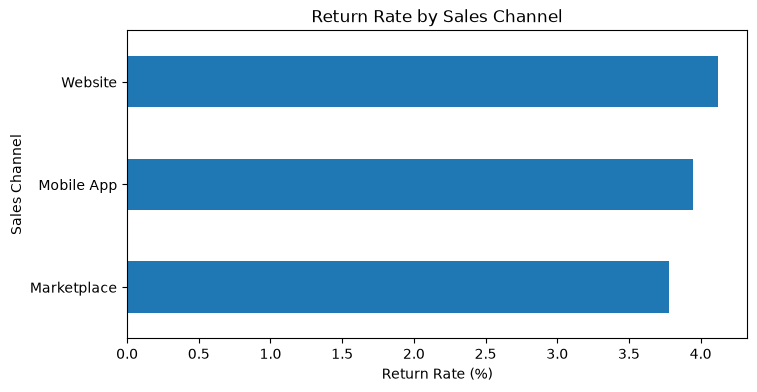

In [218]:
# Channel comparison by Chart 
return_by_channel["Returned"].sort_values().plot(
    kind="barh",
    figsize=(8, 4)
)

plt.title("Return Rate by Sales Channel")
plt.xlabel("Return Rate (%)")
plt.ylabel("Sales Channel")
plt.show()

# not giving any deeper insight though

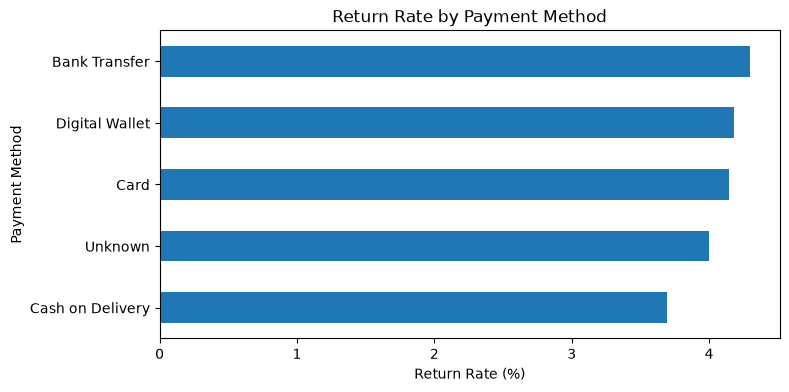

In [219]:
# for Payment method
return_by_payment["Returned"].sort_values().plot(
    kind="barh",
    figsize=(8, 4)
)

plt.title("Return Rate by Payment Method")
plt.xlabel("Return Rate (%)")
plt.ylabel("Payment Method")
plt.show()

### Covered so far
Overall performance: Net Sales, Gross Profit, orders, customers, units and AOV.
Distribution/outliers: order values, quantities, discounts and gross margins; investigated rather than blindly removed outliers.
Time analysis: monthly sales/profit trends, seasonality and 2024–2025 YoY performance.
Product analysis: categories, subcategories, individual products, sales contribution, margins and negative-margin transactions.
Customer analysis: customer segments, customer value/repeat behavior and acquisition channels.
Order/channel analysis: Website/Mobile App/Marketplace, payment methods, cancellations and return rates.
Business investigation: especially the strong relationship between 25–30% discounts and negative-margin transactions.

# Business Insights & Recommendations

## Business Insights

Based on the results we've established, your strongest insights are likely these:

1. Sales growth came from higher order value, not higher volume. Net Sales increased 1.46% YoY in 2025, while orders declined 0.06% and units sold declined 0.16%. AOV increased 1.52%, indicating that larger-value orders drove the revenue growth.
2. Profitability improved faster than sales. Gross Profit increased 2.51%, faster than the 1.46% growth in Net Sales. This indicates improved overall profitability in 2025.
3. Electronics is the major revenue and profit driver. It generated approximately 219.27M Net Sales, 70.85M Gross Profit, and 47.41% of total sales, while also having the highest category margin at 32.31%. This also means the business has considerable revenue concentration in one category.
4. High discounts create a clear profitability concern. There were 706 completed order lines with negative gross margins. Of these, 703 (99.6%) had discounts of 25% or 30%. The business should therefore review high-discount rules, particularly where the discounted selling price falls below product cost.
5. Year-end months are particularly strong. November and December showed substantial sales and profit increases in both years, with December 2025 producing the strongest monthly performance. With only two years of data, this suggests rather than conclusively establishes year-end seasonality.
6. Customer segments differ mainly in scale, not order value. Consumer customers generated the largest sales and order volume, but AOV was similar across Consumer (21,562), Home Office (21,514) and Small Business (21,128). Consumer dominance therefore comes primarily from having more customers/orders rather than materially larger purchases.
7. Acquisition channels show different customer-value patterns. Organic Search generated the highest total Net Sales, whereas Paid Search produced the highest AOV and Sales per Customer. Marketing-cost data would be needed before determining which channel provides the best acquisition efficiency or return.
8. Sales-channel revenue differences are mostly volume-driven. Website generated 210.54M, Mobile App 182.32M, and Marketplace 69.64M, while their AOVs were relatively similar at roughly 21.3K–21.7K. Increasing Marketplace order volume may therefore be more relevant than attempting to increase its already-comparable AOV.

## Recommendations
1. Review high-discount pricing policies.
The strongest actionable finding concerns discounts of 25–30%, which account for almost all negative-margin transactions. Management should introduce margin checks before approving high discounts and consider setting product-specific discount limits based on unit cost and expected profitability. High discounts may still be appropriate for strategic purposes, but they should not routinely reduce selling prices below cost.

2. Protect the strong performance of Electronics while reducing revenue concentration risk.
Electronics contributes approximately 47% of total Net Sales and also delivers the highest category profit margin. Maintaining product availability and competitive positioning in this category should therefore remain a priority. At the same time, the high dependence on Electronics creates concentration risk, so opportunities to grow profitable subcategories in Sports & Outdoors, Home & Living, and other categories should be explored.

3. Focus on increasing order volume to support future growth.
Net Sales grew in 2025 despite a slight decline in both order count and units sold, primarily because AOV increased. Relying mainly on higher order values may not provide sustainable growth. Customer acquisition, repeat-purchase initiatives, and targeted promotions should therefore focus on increasing the number of profitable orders without relying excessively on discounts.

4. Prepare for stronger year-end demand.
November and December produced substantial increases in sales and gross profit in both years analyzed. Inventory planning, product availability, marketing activity, and operational capacity should be prepared in advance for this period. As the dataset contains only two years, additional historical data should be used to confirm whether this pattern represents consistent seasonality.

5. Investigate opportunities to strengthen lower-performing product areas.
Performance varies considerably across categories, subcategories, and individual products. Low-sales products should not automatically be discontinued, as some maintain healthy margins. Management should evaluate both sales volume and profitability when making assortment decisions, while paying particular attention to products that combine low demand with weak margins.

6. Use acquisition-channel performance together with marketing costs.
Organic Search generates the highest overall Net Sales, while Paid Search produces the highest AOV and Sales per Customer. This suggests different strengths across acquisition channels. Before increasing or reallocating marketing expenditure, acquisition cost and campaign-spend data should be incorporated to compare customer acquisition cost and return on marketing investment.

7. Prioritize sales-channel volume rather than AOV differences.
Website, Mobile App, and Marketplace have relatively similar average order values, while their total sales differ considerably because of order volume. Growth efforts should therefore focus on increasing qualified traffic and completed transactions, particularly in lower-volume channels, rather than primarily attempting to increase order size.

8. Continue monitoring cancellations, returns, and profitability together.
Cancellation and return rates should be monitored by sales channel, payment method, product category, and product. Combining these operational indicators with margin data can help identify areas that generate apparent sales but ultimately contribute less value because of cancellations, returns, or excessive discounting.